SOAL 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')

In [2]:
# --- 2. FUNGSI PREPROCESSING ---
# Di preprocessing — fix fillna syntax (pandas >= 2.0)
def load_and_preprocess_data(file_path='data_train.csv'):
    df = pd.read_csv(file_path)

    df['Gender']         = df['Gender'].fillna(df['Gender'].mode()[0])
    df['Married']        = df['Married'].fillna(df['Married'].mode()[0])
    df['Dependents']     = df['Dependents'].fillna(df['Dependents'].mode()[0])
    df['Self_Employed']  = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
    df['LoanAmount']     = df['LoanAmount'].fillna(df['LoanAmount'].median())
    df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
    df['Credit_History'] = df['Credit_History'].fillna(0)
    df['CoapplicantIncome'] = df['CoapplicantIncome'].fillna(0)

    df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
    return df

In [3]:
# --- 3. CLASS MANUAL FIS  ---
class ManualFIS:
    """
    Fuzzy Inference System (Mamdani Type) untuk Prediksi Kelayakan Kredit
    Menggunakan pendekatan manual berdasarkan intuisi dan logika manusia
    """

    def __init__(self):
        self.rules = []
        self.mf_params = {}
        self._initialize_membership_functions()
        self._initialize_rules()

    def _initialize_membership_functions(self):
      self.mf_params['income'] = {
        'low':    [0, 0, 4000, 6000],
        'medium': [4000, 6000, 8000, 10000],
        'high':   [8000, 12000, 100000, 100000]
    }
      self.mf_params['loan_amount'] = {
        'small':  [0, 0, 100, 150],
        'medium': [100, 150, 250, 350],
        'large':  [250, 350, 700, 700]
    }
      self.mf_params['credit_history'] = {
        'bad':  [0, 0, 0.3, 0.5],
        'good': [0.5, 0.7, 1.0, 1.0]
    }
      self.mf_params['income_ratio'] = {
        'low':    [0, 0, 20, 40],
        'medium': [20, 40, 60, 80],
        'high':   [60, 100, 99999, 99999]
    }
      self.mf_params['approval'] = {
        'reject':  [0, 0, 20, 45],
        'review':  [35, 50, 60, 75],
        'approve': [60, 80, 100, 100]
    }

    def _trapezoidal_mf(self, x, params):
        """Fungsi keanggotaan trapezoidal"""
        a, b, c, d = params
        if x < a or x > d:
            return 0.0
        elif a < x <= b:
            return (x - a) / (b - a) if b != a else 1.0
        elif b < x <= c:
            return 1.0
        else:  # c < x < d
            return (d - x) / (d - c) if d != c else 1.0

    def _fuzzify(self, value, variable):
        """Fuzzifikasi: mengkonversi input crisp menjadi fuzzy"""
        memberships = {}
        for label, params in self.mf_params[variable].items():
            memberships[label] = self._trapezoidal_mf(value, params)
        return memberships

    def _initialize_rules(self):
        """11 Rules Lengkap berdasarkan intuisi Keyna"""
        self.rules.append({'conditions': {'credit_history': 'good', 'income_ratio': 'high'}, 'output': 'approve', 'weight': 1.0})
        self.rules.append({'conditions': {'credit_history': 'good', 'income_ratio': 'medium', 'income': 'high'}, 'output': 'approve', 'weight': 0.9})
        self.rules.append({'conditions': {'credit_history': 'good', 'income_ratio': 'medium', 'loan_amount': 'small'}, 'output': 'approve', 'weight': 0.85})
        self.rules.append({'conditions': {'credit_history': 'good', 'income': 'medium', 'loan_amount': 'small'}, 'output': 'approve', 'weight': 0.8})
        self.rules.append({'conditions': {'credit_history': 'good', 'income_ratio': 'low'}, 'output': 'review', 'weight': 0.7})
        self.rules.append({'conditions': {'credit_history': 'bad', 'income_ratio': 'high'}, 'output': 'review', 'weight': 0.6})
        self.rules.append({'conditions': {'credit_history': 'bad', 'income': 'high', 'loan_amount': 'small'}, 'output': 'review', 'weight': 0.65})
        self.rules.append({'conditions': {'credit_history': 'bad', 'income_ratio': 'low'}, 'output': 'reject', 'weight': 1.0})
        self.rules.append({'conditions': {'credit_history': 'bad', 'loan_amount': 'large'}, 'output': 'reject', 'weight': 1.0})
        self.rules.append({'conditions': {'income': 'low', 'loan_amount': 'large'}, 'output': 'reject', 'weight': 0.90})
        self.rules.append({'conditions': {'income': 'low', 'credit_history': 'bad'}, 'output': 'reject', 'weight': 0.95})


    def _evaluate_rules(self, fuzzy_inputs):
        """Evaluasi semua rules dan hitung activation strength (Logika Original)"""
        activations = {'reject': 0, 'review': 0, 'approve': 0}

        for rule in self.rules:
            # Hitung strength dengan AND operator (minimum)
            strengths = []
            for var, label in rule['conditions'].items():
                if var in fuzzy_inputs:
                    strengths.append(fuzzy_inputs[var].get(label, 0))

            if strengths:
                rule_strength = min(strengths) * rule['weight']
                output = rule['output']
                activations[output] = max(activations[output], rule_strength)

        return activations

    def _defuzzify(self, activations):
        """Defuzzifikasi menggunakan Centroid method (Logika Original)"""
        # Generate output universe
        x = np.linspace(0, 100, 1000)
        aggregated = np.zeros_like(x)

        # Aggregate all activated outputs
        for output_label, strength in activations.items():
            if strength > 0:
                params = self.mf_params['approval'][output_label]
                mf_values = np.array([self._trapezoidal_mf(xi, params) for xi in x])
                # Clip membership function dengan activation strength
                clipped = np.minimum(mf_values, strength)
                aggregated = np.maximum(aggregated, clipped)

        # Centroid defuzzification
        if aggregated.sum() == 0:
            return 50  # Default jika tidak ada aktivasi

        centroid = np.sum(x * aggregated) / np.sum(aggregated)
        return centroid

    def predict_single(self, income, loan_amount, credit_history, coapplicant_income=0):
        """Prediksi untuk satu sampel (Logika Original)"""
        # Hitung total income
        total_income = income + coapplicant_income

        # Hitung income ratio
        income_ratio = (total_income / loan_amount) if loan_amount > 0 else 100

        # Fuzzifikasi inputs
        fuzzy_inputs = {
            'income': self._fuzzify(total_income, 'income'),
            'loan_amount': self._fuzzify(loan_amount, 'loan_amount'),
            'credit_history': self._fuzzify(credit_history, 'credit_history'),
            'income_ratio': self._fuzzify(income_ratio, 'income_ratio')
        }

        # Evaluasi rules
        activations = self._evaluate_rules(fuzzy_inputs)

        # Defuzzifikasi
        score = self._defuzzify(activations)

        # Threshold untuk keputusan final (52 adalah batas)
        prediction = 1 if score >= 52 else 0

        return prediction, score, activations

    def predict(self, X):
        """Prediksi untuk multiple samples (Logika Original dg Looping)"""
        predictions = []
        scores = []

        # Menggunakan loop persis seperti draf awalmu
        for i in range(len(X)):
            income = X.iloc[i]['ApplicantIncome']
            coapplicant_income = X.iloc[i]['CoapplicantIncome']
            loan_amount = X.iloc[i]['LoanAmount']
            credit_history = X.iloc[i]['Credit_History']

            pred, score, _ = self.predict_single(income, loan_amount, credit_history, coapplicant_income)
            predictions.append(pred)
            scores.append(score)

        return np.array(predictions), np.array(scores)

    def visualize_membership_functions(self, save_path='mf_visualization.png'):
        """Visualisasi semua membership functions"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle('Manual Membership Functions (Human Intuition)', fontsize=16, fontweight='bold')

        variables = [
            ('income', 'Applicant Income', 0, 50000, axes[0, 0]),
            ('loan_amount', 'Loan Amount', 0, 700, axes[0, 1]),
            ('credit_history', 'Credit History', 0, 1, axes[0, 2]),
            ('income_ratio', 'Income to Loan Ratio', 0, 200, axes[1, 0]),
            ('approval', 'Loan Approval Score', 0, 100, axes[1, 1])
        ]

        for var_name, title, x_min, x_max, ax in variables:
            x = np.linspace(x_min, x_max, 500)
            for label, params in self.mf_params[var_name].items():
                y = [self._trapezoidal_mf(xi, params) for xi in x]
                ax.plot(x, y, label=label, linewidth=2)

            ax.set_title(title, fontweight='bold')
            ax.set_xlabel('Value')
            ax.set_ylabel('Membership Degree')
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.set_ylim(-0.05, 1.05)

        axes[1, 2].axis('off')
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Membership functions visualization saved to {save_path}")
        return fig

In [4]:
# --- 4. FUNGSI EVALUASI & MAIN ---
def evaluate_model(fis, X_test, y_test):
    """Evaluasi performa model (Logika Original)"""
    predictions, scores = fis.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    print("="*60)
    print("TAHAP 1: MANUAL FIS EVALUATION RESULTS")
    print("="*60)
    print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print("\nClassification Report:")
    print(classification_report(y_test, predictions, target_names=['Rejected', 'Approved']))

    cm = confusion_matrix(y_test, predictions)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Rejected', 'Approved'],
                yticklabels=['Rejected', 'Approved'])
    axes[0].set_title('Confusion Matrix - Manual FIS', fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    axes[1].hist(scores, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[1].axvline(52, color='red', linestyle='--', linewidth=2, label='Decision Threshold')
    axes[1].set_title('Distribution of Approval Scores', fontweight='bold')
    axes[1].set_xlabel('Approval Score')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('manual_fis_evaluation.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\nEvaluation visualization saved to manual_fis_evaluation.png")

    return accuracy, predictions, scores

Memproses data...
Training samples: 429
Testing samples: 185

Initializing Manual Fuzzy Inference System...

Visualizing Membership Functions...


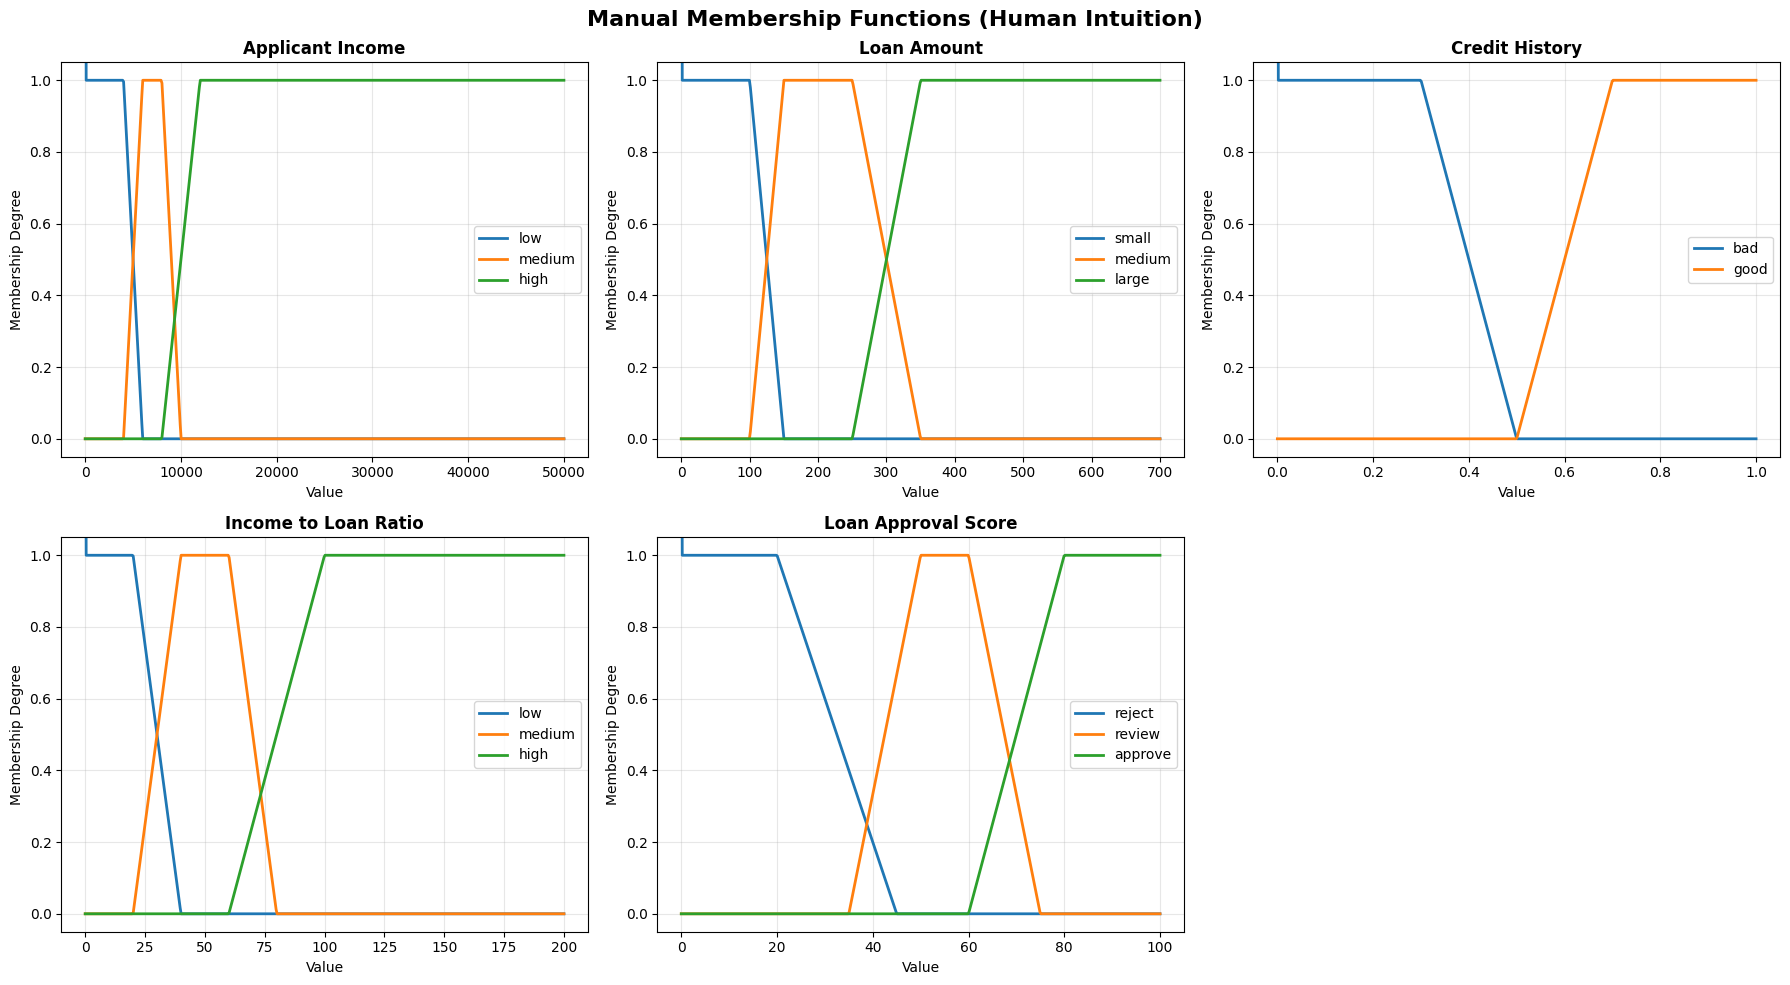

Membership functions visualization saved to mf_visualization.png

Evaluating Manual FIS on test data...
TAHAP 1: MANUAL FIS EVALUATION RESULTS

Accuracy: 0.7622 (76.22%)

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.71      0.55      0.62        65
    Approved       0.78      0.88      0.83       120

    accuracy                           0.76       185
   macro avg       0.74      0.71      0.72       185
weighted avg       0.76      0.76      0.75       185



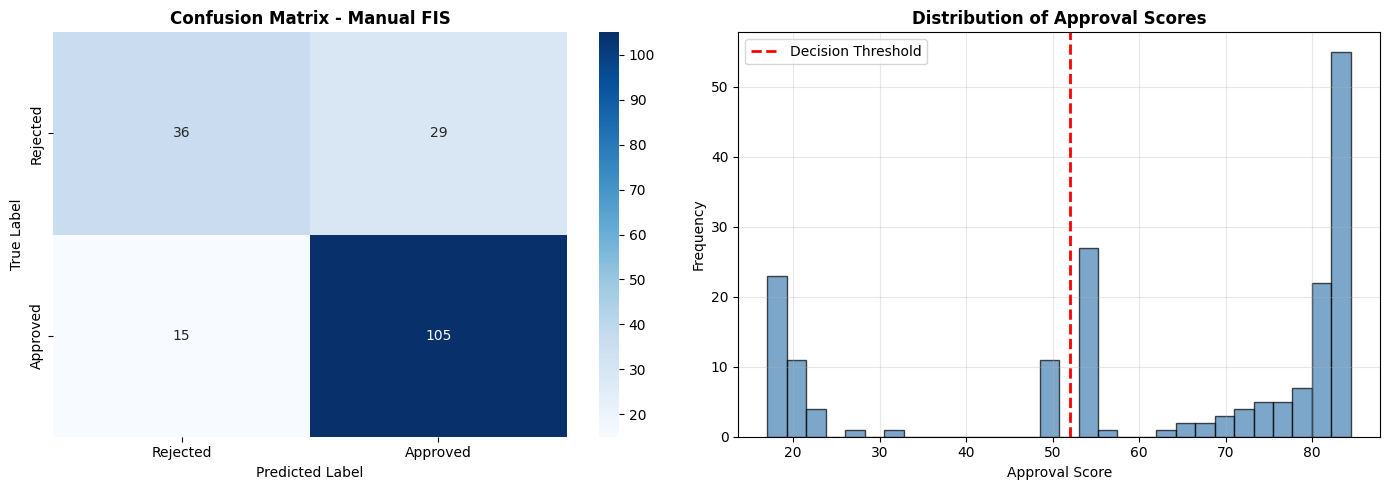


Evaluation visualization saved to manual_fis_evaluation.png

MANUAL FIS SETUP COMPLETE
Total Fuzzy Rules: 11
Initial Accuracy: 0.7622

This manual FIS will serve as baseline for GA and ANN optimization.


In [5]:
def main():
    print("Memproses data...")
    df = load_and_preprocess_data('data_train.csv')

    features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Credit_History']
    X = df[features]
    y = df['Loan_Status']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    print(f"Training samples: {len(X_train)}")
    print(f"Testing samples: {len(X_test)}")

    print("\nInitializing Manual Fuzzy Inference System...")
    fis = ManualFIS()

    print("\nVisualizing Membership Functions...")
    fis.visualize_membership_functions()

    print("\nEvaluating Manual FIS on test data...")
    accuracy, predictions, scores = evaluate_model(fis, X_test, y_test)

    print("\n" + "="*60)
    print("MANUAL FIS SETUP COMPLETE")
    print("="*60)
    print(f"Total Fuzzy Rules: {len(fis.rules)}")
    print(f"Initial Accuracy: {accuracy:.4f}")
    print("\nThis manual FIS will serve as baseline for GA and ANN optimization.")

    return fis, accuracy, df

if __name__ == "__main__":
    fis, accuracy, df = main()

SOAL 2

In [46]:
# ============================================================
# TAHAP 2 - CELL 1: Import Library
# ============================================================

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    balanced_accuracy_score, f1_score
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [47]:
# ============================================================
# TAHAP 2 - CELL 2: Struktur Chromosome  [TIDAK BERUBAH]
# ============================================================
# Chromosome = representasi satu "individu" dalam populasi GA
# Satu chromosome = semua parameter MF + 1 gen threshold
#
# Format akhir:
#   [income_low_a, ..., approval_approve_d,  threshold]
#
# Total: 56 parameter MF  +  1 threshold  =  57 nilai float

STRUCTURE = {
    'income':         ['low', 'medium', 'high'],
    'loan_amount':    ['small', 'medium', 'large'],
    'credit_history': ['bad', 'good'],
    'income_ratio':   ['low', 'medium', 'high'],
    'approval':       ['reject', 'review', 'approve'],
}

BOUNDS = {
    'income': {
        'low':    [(0,0),      (0,0),          (1000,6000),    (2000,8000)],
        'medium': [(1000,5000),(3000,8000),     (5000,12000),   (7000,15000)],
        'high':   [(5000,10000),(8000,15000),   (50000,100000), (50000,100000)],
    },
    'loan_amount': {
        'small':  [(0,0),    (0,0),      (50,150),   (80,200)],
        'medium': [(50,150), (100,200),  (200,350),  (250,450)],
        'large':  [(200,350),(300,450),  (600,700),  (600,700)],
    },
    'credit_history': {
        'bad':  [(0,0),(0,0),      (0.1,0.5),(0.3,0.7)],
        'good': [(0.3,0.6),(0.5,0.8),(1.0,1.0),(1.0,1.0)],
    },
    'income_ratio': {
        'low':    [(0,0),    (0,0),     (10,30),       (20,50)],
        'medium': [(10,40),  (20,50),   (40,80),        (60,100)],
        'high':   [(40,80),  (70,120),  (9000,99999),   (9000,99999)],
    },
    'approval': {
        'reject':  [(0,0),   (0,0),    (10,30),  (25,50)],
        'review':  [(20,40), (40,55),  (50,65),  (60,80)],
        'approve': [(50,70), (65,85),  (100,100),(100,100)],
    },
}

# REVISI: Batas threshold dioptimasi bersama chromosome MF
THRESHOLD_BOUNDS = (35.0, 75.0)  # [a] threshold masuk sebagai gen ke-57

print("Struktur chromosome didefinisikan.")
print(f"Total parameter MF    : {sum(len(v)*4 for v in STRUCTURE.values())} nilai")
print(f"Total + gen threshold : {sum(len(v)*4 for v in STRUCTURE.values()) + 1} nilai")

Struktur chromosome didefinisikan.
Total parameter MF    : 56 nilai
Total + gen threshold : 57 nilai


In [48]:
# ============================================================
# TAHAP 2 - CELL 3: Encode & Decode Chromosome  [REVISI]
# ============================================================

def chromosome_to_params(chrom):
    """Array angka → dict MF params (56 gen pertama)."""
    params = {}
    idx = 0
    for var, labels in STRUCTURE.items():
        params[var] = {}
        for label in labels:
            bounds = BOUNDS[var][label]
            vals = []
            for j in range(4):
                lo, hi = bounds[j]
                v = np.clip(chrom[idx + j], lo, hi)
                vals.append(v)
            vals = list(np.sort(vals))
            params[var][label] = vals
            idx += 4
    return params

def chromosome_to_threshold(chrom):
    """Ambil gen threshold dari posisi terakhir chromosome."""
    lo, hi = THRESHOLD_BOUNDS
    return float(np.clip(chrom[-1], lo, hi))

def params_to_chromosome(mf_params, threshold=52.0):
    """Dict MF params + threshold → array angka."""
    chrom = []
    for var, labels in STRUCTURE.items():
        for label in labels:
            chrom.extend(mf_params[var][label])
    chrom.append(threshold)
    return np.array(chrom, dtype=float)

def random_chromosome():
    """Buat satu individu acak yang valid sesuai BOUNDS."""
    chrom = []
    for var, labels in STRUCTURE.items():
        for label in labels:
            bounds = BOUNDS[var][label]
            vals = [np.random.uniform(lo, hi) if hi > lo else lo
                    for (lo, hi) in bounds]
            vals = sorted(vals)
            chrom.extend(vals)
    # Gen threshold acak
    lo, hi = THRESHOLD_BOUNDS
    chrom.append(np.random.uniform(lo, hi))
    return np.array(chrom, dtype=float)

# Test cepat
test_chrom  = random_chromosome()
test_params = chromosome_to_params(test_chrom)
test_thr    = chromosome_to_threshold(test_chrom)
print(f"Panjang chromosome (dengan threshold) : {len(test_chrom)}")
print(f"Threshold dari gen terakhir           : {test_thr:.2f}")

Panjang chromosome (dengan threshold) : 57
Threshold dari gen terakhir           : 49.87


In [49]:
# ============================================================
# TAHAP 2 - CELL 3B: Data Split & Preprocessing  [REVISI — FIX DATA LEAKAGE]
# ============================================================
# REVISI: fillna dilakukan SETELAH split, menggunakan median/mode dari
# X_train saja, sehingga X_val dan X_test tidak "bocor" informasi
# dari distribusi data yang belum seharusnya dilihat.

def split_and_preprocess(X_raw, y, test_size=0.30, val_ratio=0.33, random_state=42):
    """
    Split data → Train / Val / Test, lalu isi missing values
    menggunakan statistik dari X_train SAJA (tanpa data leakage).

    Returns
    -------
    X_train, X_val, X_test, y_train, y_val, y_test  (semua pd.DataFrame / Series)
    train_medians  : dict median X_train (untuk referensi / audit)
    """
    # Step 1: Split dulu, sebelum apapun
    X_temp,  X_test,  y_temp,  y_test  = train_test_split(
        X_raw, y, test_size=test_size, random_state=random_state
    )
    X_train, X_val,   y_train, y_val   = train_test_split(
        X_temp, y_temp, test_size=val_ratio, random_state=random_state
    )

    # Step 2: Hitung statistik HANYA dari X_train
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    train_medians = {col: X_train[col].median() for col in numeric_cols}

    # Step 3: Isi missing values menggunakan median X_train
    for split_df in [X_train, X_val, X_test]:
        for col in numeric_cols:
            split_df[col] = split_df[col].fillna(train_medians[col])

    return X_train, X_val, X_test, y_train, y_val, y_test, train_medians

In [50]:
# ============================================================
# TAHAP 2 - CELL 4: Fitness Function  [REVISI — ROBUST + DYNAMIC THRESHOLD]
# ============================================================

# ── Helper: cek konsistensi linguistik antar-label MF ──────────────────────
def _mf_linguistic_penalty(params):
    """
    Periksa apakah urutan titik tengah (c-values) antar label masuk akal:
      income   : low.c  < medium.c  < high.c
      loan     : small.c < medium.c < large.c
      ratio    : low.c  < medium.c  < high.c
      credit   : bad.c  < good.c
      approval : reject.c < review.c < approve.c

    Jika ada pelanggaran → kembalikan nilai penalti > 0.
    Besar penalti proporsional dengan besarnya overlap.
    """
    PENALTY_WEIGHT = 2.0
    total_violation = 0.0

    ordered_vars = {
        'income':         ['low',    'medium', 'high'],
        'loan_amount':    ['small',  'medium', 'large'],
        'credit_history': ['bad',    'good'],
        'income_ratio':   ['low',    'medium', 'high'],
        'approval':       ['reject', 'review', 'approve'],
    }

    for var, labels in ordered_vars.items():
        for i in range(len(labels) - 1):
            # Gunakan titik c (indeks 2) sebagai representasi "pusat atas" trapesium
            c_curr = params[var][labels[i]][2]
            c_next = params[var][labels[i + 1]][2]
            if c_curr >= c_next:
                # Besarnya overlap = selisih negatif (semakin besar semakin parah)
                total_violation += (c_curr - c_next + 1e-6)

    return PENALTY_WEIGHT * total_violation


class GA_FIS(ManualFIS):
    """ManualFIS yang parameter MF dan threshold-nya bisa diganti dari chromosome."""

    def set_params(self, chrom):
        self.mf_params        = chromosome_to_params(chrom)
        self.decision_threshold = chromosome_to_threshold(chrom)

    def predict_single(self, income, loan_amount, credit_history, coapplicant_income=0):
        total_income = income + coapplicant_income
        income_ratio = (total_income / loan_amount) if loan_amount > 0 else 100

        fuzzy_inputs = {
            'income':         self._fuzzify(total_income,    'income'),
            'loan_amount':    self._fuzzify(loan_amount,     'loan_amount'),
            'credit_history': self._fuzzify(credit_history,  'credit_history'),
            'income_ratio':   self._fuzzify(income_ratio,    'income_ratio'),
        }
        activations = self._evaluate_rules(fuzzy_inputs)
        score       = self._defuzzify(activations)

        # REVISI: threshold dinamis dari gen chromosome, bukan angka kaku 52
        prediction  = 1 if score >= self.decision_threshold else 0
        return prediction, score, activations


def hitung_fitness(chrom, X_val, y_val):
    """
    REVISI — Robust Fitness Function:
    1. Threshold diambil dari gen terakhir chromosome (dinamis).
    2. Metrik = 0.4 × balanced_accuracy + 0.6 × f1_macro
       → lebih tahan terhadap class imbalance.
    3. Penalti linguistik jika urutan label MF tidak logis.
    """
    fis = GA_FIS()
    fis.set_params(chrom)

    try:
        preds, _ = fis.predict(X_val)

        # ── Metrik robust ──────────────────────────────────────────────────
        bal_acc = balanced_accuracy_score(y_val, preds)
        f1_mac  = f1_score(y_val, preds, average='macro', zero_division=0)
        base_score = 0.4 * bal_acc + 0.6 * f1_mac

        # ── Penalti linguistik ─────────────────────────────────────────────
        params  = chromosome_to_params(chrom)
        penalty = _mf_linguistic_penalty(params)

        # Skala penalti relatif terhadap skor (maks 1.0)
        # penalty sudah dalam unit "unit nilai MF" → normalisasi agar
        # satu violation kecil tidak langsung memusnahkan individu
        normalized_penalty = min(penalty / 1000.0, base_score * 0.8)

        fitness = base_score - normalized_penalty
        return max(fitness, 0.0)

    except Exception:
        return 0.0

In [51]:
# ============================================================
# TAHAP 2 - CELL 5: Operator GA  [REVISI — Sorted Mutation + Dynamic Rate]
# ============================================================

def seleksi_tournament(populasi, fitnesses, k=3):
    """
    Pilih 1 induk: adu k individu acak, yang fitness tertinggi menang.
    """
    idx      = np.random.choice(len(populasi), k, replace=False)
    pemenang = idx[np.argmax([fitnesses[i] for i in idx])]
    return populasi[pemenang].copy()


def crossover_blx(p1, p2, alpha=0.3):
    """
    BLX-α Crossover.
    """
    anak = np.empty_like(p1)
    for i in range(len(p1)):
        lo, hi  = sorted([p1[i], p2[i]])
        jarak   = hi - lo
        anak[i] = np.random.uniform(lo - alpha * jarak, hi + alpha * jarak)
    return anak


def clip_to_bounds(chrom):
    """
    Clip nilai chromosome ke BOUNDS yang valid, lalu paksa a≤b≤c≤d.
    Gen threshold (terakhir) di-clip ke THRESHOLD_BOUNDS.
    """
    hasil = chrom.copy()
    idx   = 0
    for var, labels in STRUCTURE.items():
        for label in labels:
            bounds = BOUNDS[var][label]
            for j in range(4):
                lo, hi = bounds[j]
                if hi > lo:
                    hasil[idx + j] = np.clip(hasil[idx + j], lo, hi)
            hasil[idx:idx + 4] = sorted(hasil[idx:idx + 4])
            idx += 4
    # Clip gen threshold
    lo, hi = THRESHOLD_BOUNDS
    hasil[-1] = np.clip(hasil[-1], lo, hi)
    return hasil


def mutasi_gaussian(chrom, mutation_rate=0.1, stagnation_factor=1.0):
    """
    REVISI — Refined Mutation:
    1. `stagnation_factor` > 1 memperbesar loncatan mutasi saat GA stagnan
       (mutation_rate efektif = mutation_rate × stagnation_factor, maks 0.4).
    2. Setelah mutasi, setiap gen di-clip ke bounds-nya masing-masing,
       lalu diurutkan ulang per-label agar trapezoid tetap valid (a≤b≤c≤d).
    3. Gen threshold di-clip ke THRESHOLD_BOUNDS.
    """
    effective_rate = min(mutation_rate * stagnation_factor, 0.40)

    hasil = chrom.copy()
    idx   = 0
    for var, labels in STRUCTURE.items():
        for label in labels:
            bounds = BOUNDS[var][label]
            for j in range(4):
                if np.random.random() < effective_rate:
                    noise          = np.random.normal(0, 0.05 * abs(hasil[idx + j]) + 1e-5)
                    hasil[idx + j] += noise
                    lo, hi         = bounds[j]
                    if hi > lo:
                        hasil[idx + j] = np.clip(hasil[idx + j], lo, hi)
            # Paksa urutan a≤b≤c≤d
            hasil[idx:idx + 4] = sorted(hasil[idx:idx + 4])
            idx += 4

    # Mutasi gen threshold
    if np.random.random() < effective_rate:
        noise       = np.random.normal(0, 2.0)   # noise ±2 poin threshold
        hasil[-1]  += noise
        lo, hi      = THRESHOLD_BOUNDS
        hasil[-1]   = np.clip(hasil[-1], lo, hi)

    return hasil

In [52]:
# ============================================================
# TAHAP 2 - CELL 6: Main GA Loop  [REVISI — Dynamic Mutation Rate]
# ============================================================

def jalankan_ga(X_val, y_val,
                pop_size=40, n_gen=80,
                mutation_rate=0.05, crossover_rate=0.8,
                elitism=3, verbose=True, label="GA"):
    """
    Jalankan GA.

    REVISI:
    - Chromosome sekarang berisi 57 gen (56 MF + 1 threshold).
    - Fitness menggunakan balanced_accuracy + f1_macro.
    - Mutation rate dinamis: naik 50% jika 10 generasi tidak ada perbaikan
      (mencegah premature convergence), lalu turun kembali.
    - Clip + sort setelah crossover dan mutasi.
    """
    populasi    = [random_chromosome() for _ in range(pop_size)]
    seed_params = ManualFIS().mf_params
    seed_chrom  = params_to_chromosome(seed_params, threshold=52.0)
    populasi[0] = seed_chrom.copy()

    history       = {'best': [], 'mean': [], 'worst': []}
    best_chrom    = seed_chrom.copy()
    best_fitness  = hitung_fitness(seed_chrom, X_val, y_val)

    no_improve_streak = 0
    current_mut_rate  = mutation_rate

    if verbose:
        print(f"\n{'='*58}")
        print(f"  {label}")
        print(f"  Pop: {pop_size} | Gen: {n_gen} | Mut base: {mutation_rate}")
        print(f"  Fitness: 0.4×BalAcc + 0.6×F1_macro + linguistic penalty")
        print(f"  Threshold: gen ke-57 (batas {THRESHOLD_BOUNDS[0]}–{THRESHOLD_BOUNDS[1]})")
        print(f"{'='*58}")

    for gen in range(n_gen):
        fitnesses    = [hitung_fitness(c, X_val, y_val) for c in populasi]
        idx_terbaik  = np.argmax(fitnesses)

        if fitnesses[idx_terbaik] > best_fitness + 1e-5:
            best_fitness       = fitnesses[idx_terbaik]
            best_chrom         = populasi[idx_terbaik].copy()
            no_improve_streak  = 0
            current_mut_rate   = mutation_rate          # reset ke default
        else:
            no_improve_streak += 1

        # ── Dynamic mutation rate ──────────────────────────────────────────
        if no_improve_streak >= 10:
            current_mut_rate = min(mutation_rate * 2.0, 0.40)
        if no_improve_streak >= 20:
            if verbose:
                print(f"\n  Early stopping di generasi {gen+1} (stagnasi {no_improve_streak} gen)")
            break

        history['best'].append(fitnesses[idx_terbaik])
        history['mean'].append(np.mean(fitnesses))
        history['worst'].append(np.min(fitnesses))

        if verbose and (gen % 10 == 0 or gen == n_gen - 1):
            thr = chromosome_to_threshold(best_chrom)
            print(f"  Gen {gen+1:3d} | Best: {fitnesses[idx_terbaik]:.4f} "
                  f"| Mean: {np.mean(fitnesses):.4f} "
                  f"| Overall: {best_fitness:.4f} "
                  f"| Thr: {thr:.1f} | MutRate: {current_mut_rate:.3f}")

        # ── Buat generasi baru ────────────────────────────────────────────
        urut          = np.argsort(fitnesses)[::-1]
        generasi_baru = [populasi[i].copy() for i in urut[:elitism]]

        # Pastikan best_chrom global selalu ada di elitism
        if not any(np.allclose(best_chrom, e) for e in generasi_baru):
            generasi_baru[0] = best_chrom.copy()

        stagnation_factor = 1.0 + 0.5 * (no_improve_streak / max(n_gen * 0.3, 1))

        while len(generasi_baru) < pop_size:
            induk1 = seleksi_tournament(populasi, fitnesses)
            if np.random.random() < crossover_rate:
                induk2 = seleksi_tournament(populasi, fitnesses)
                anak   = crossover_blx(induk1, induk2)
                anak   = clip_to_bounds(anak)
            else:
                anak   = induk1.copy()
            anak = mutasi_gaussian(anak, current_mut_rate, stagnation_factor)
            generasi_baru.append(anak)

        populasi = generasi_baru

    if verbose:
        thr_final = chromosome_to_threshold(best_chrom)
        print(f"\n  Best fitness     : {best_fitness:.4f}")
        print(f"  Threshold optimal: {thr_final:.2f}")

    return best_chrom, best_fitness, history

In [53]:
# ============================================================
# TAHAP 2 - CELL 7: Split Data & Jalankan GA Utama  [REVISI]
# ============================================================

features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Credit_History']
X_raw    = df[features].copy()
y        = df['Loan_Status']

# REVISI: split + preprocessing tanpa data leakage
X_train, X_val, X_test, y_train, y_val, y_test, train_medians = \
    split_and_preprocess(X_raw, y, test_size=0.30, val_ratio=0.33, random_state=42)

print(f"Train : {len(X_train)} sampel")
print(f"Val   : {len(X_val)}   sampel  ← dipakai GA sebagai fitness")
print(f"Test  : {len(X_test)}  sampel  ← blind test, hanya di akhir")
print(f"\nMedian X_train (digunakan isi missing values):")
for col, med in train_medians.items():
    print(f"  {col}: {med:.4f}")

# Baseline Manual FIS (threshold 52 statis)
fis_baseline     = ManualFIS()
preds_val_bl, _  = fis_baseline.predict(X_val)
preds_test_bl, _ = fis_baseline.predict(X_test)

accuracy_val_bl   = accuracy_score(y_val,   preds_val_bl)
accuracy_test_bl  = accuracy_score(y_test,  preds_test_bl)
f1_val_bl         = f1_score(y_val,  preds_val_bl,  average='macro', zero_division=0)
f1_test_bl        = f1_score(y_test, preds_test_bl, average='macro', zero_division=0)

# Baseline fitness (skala yang sama dengan GA) — untuk perbandingan
bal_acc_val_bl    = balanced_accuracy_score(y_val,  preds_val_bl)
baseline_fitness  = 0.4 * bal_acc_val_bl + 0.6 * f1_val_bl

print(f"\nBaseline Manual FIS — val  set: acc={accuracy_val_bl:.4f}  f1_macro={f1_val_bl:.4f}")
print(f"Baseline Manual FIS — test set: acc={accuracy_test_bl:.4f}  f1_macro={f1_test_bl:.4f}")
print(f"Baseline fitness (skala GA)   : {baseline_fitness:.4f}")

# Jalankan GA utama
best_chrom, best_fitness, ga_history = jalankan_ga(
    X_val, y_val,
    pop_size=30,
    n_gen=60,
    mutation_rate=0.05,
    crossover_rate=0.8,
    elitism=2,
    verbose=True,
    label="GA UTAMA — Optimasi Parameter MF + Threshold"
)

# Threshold optimal yang ditemukan GA
best_threshold_ga = chromosome_to_threshold(best_chrom)
print(f"\nThreshold optimal GA: {best_threshold_ga:.2f}")

Train : 287 sampel
Val   : 142   sampel  ← dipakai GA sebagai fitness
Test  : 185  sampel  ← blind test, hanya di akhir

Median X_train (digunakan isi missing values):
  ApplicantIncome: 3900.0000
  CoapplicantIncome: 997.0000
  LoanAmount: 128.0000
  Credit_History: 1.0000

Baseline Manual FIS — val  set: acc=0.7746  f1_macro=0.6967
Baseline Manual FIS — test set: acc=0.7622  f1_macro=0.7237
Baseline fitness (skala GA)   : 0.6921

  GA UTAMA — Optimasi Parameter MF + Threshold
  Pop: 30 | Gen: 60 | Mut base: 0.05
  Fitness: 0.4×BalAcc + 0.6×F1_macro + linguistic penalty
  Threshold: gen ke-57 (batas 35.0–75.0)
  Gen   1 | Best: 0.6921 | Mean: 0.6231 | Overall: 0.6921 | Thr: 52.0 | MutRate: 0.050
  Gen  11 | Best: 0.7231 | Mean: 0.7042 | Overall: 0.7231 | Thr: 54.9 | MutRate: 0.050
  Gen  21 | Best: 0.7351 | Mean: 0.7256 | Overall: 0.7351 | Thr: 55.0 | MutRate: 0.050
  Gen  31 | Best: 0.7351 | Mean: 0.6869 | Overall: 0.7351 | Thr: 55.0 | MutRate: 0.100

  Early stopping di generasi 34 

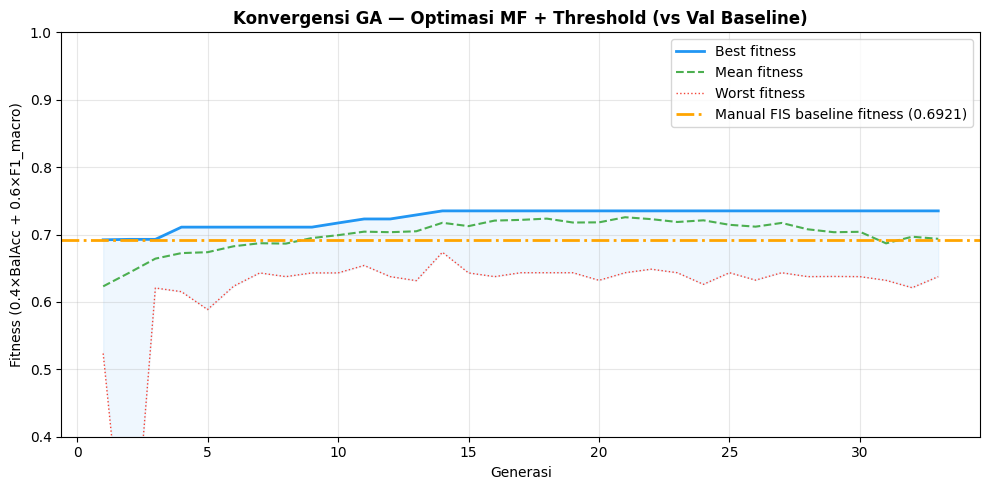


Grafik disimpan: ga_konvergensi.png


In [54]:
# ============================================================
# TAHAP 2 - CELL 8: Visualisasi Konvergensi GA  [REVISI]
# ============================================================

def plot_konvergensi(history, baseline_fitness_val, judul="GA Convergence"):
    fig, ax = plt.subplots(figsize=(10, 5))
    gen = range(1, len(history['best']) + 1)

    ax.plot(gen, history['best'],  label='Best fitness',  color='#2196F3', linewidth=2)
    ax.plot(gen, history['mean'],  label='Mean fitness',  color='#4CAF50', linewidth=1.5, linestyle='--')
    ax.plot(gen, history['worst'], label='Worst fitness', color='#F44336', linewidth=1,   linestyle=':')
    ax.axhline(baseline_fitness_val, color='orange', linewidth=2, linestyle='-.',
               label=f'Manual FIS baseline fitness ({baseline_fitness_val:.4f})')
    ax.fill_between(gen, history['worst'], history['best'], alpha=0.07, color='#2196F3')

    ax.set_title(judul, fontweight='bold')
    ax.set_xlabel('Generasi')
    ax.set_ylabel('Fitness (0.4×BalAcc + 0.6×F1_macro)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(max(0.4, min(history['worst']) - 0.05), 1.0)
    plt.tight_layout()
    plt.savefig('ga_konvergensi.png', dpi=200, bbox_inches='tight')
    plt.show()

plot_konvergensi(ga_history, baseline_fitness,
                 "Konvergensi GA — Optimasi MF + Threshold (vs Val Baseline)")
print("\nGrafik disimpan: ga_konvergensi.png")

In [55]:
# ============================================================
# TAHAP 2 - CELL 9: Perbandingan Parameter MF Manual vs GA  [TIDAK BERUBAH]
# ============================================================

def bandingkan_params(params_manual, params_ga):
    print("\n" + "="*65)
    print("  PERBANDINGAN PARAMETER MF: MANUAL vs GA-OPTIMIZED")
    print("="*65)
    for var in STRUCTURE:
        print(f"\n  [{var.upper()}]")
        for label in STRUCTURE[var]:
            m       = [round(v, 2) for v in params_manual[var][label]]
            g       = [round(v, 2) for v in params_ga[var][label]]
            berubah = m != g
            flag    = "  ← DIGESER GA" if berubah else ""
            print(f"    {label:15s} Manual: {m}")
            print(f"    {' '*15} GA    : {g}{flag}")

params_manual = ManualFIS().mf_params
params_ga     = chromosome_to_params(best_chrom)
bandingkan_params(params_manual, params_ga)
print(f"\n  Threshold Manual (statis) : 52.00")
print(f"  Threshold GA (optimal)    : {best_threshold_ga:.2f}")


  PERBANDINGAN PARAMETER MF: MANUAL vs GA-OPTIMIZED

  [INCOME]
    low             Manual: [0, 0, 4000, 6000]
                    GA    : [np.float64(0.0), np.float64(0.0), np.float64(3963.61), np.float64(5506.23)]  ← DIGESER GA
    medium          Manual: [4000, 6000, 8000, 10000]
                    GA    : [np.float64(4079.97), np.float64(7652.91), np.float64(8256.37), np.float64(11439.02)]  ← DIGESER GA
    high            Manual: [8000, 12000, 100000, 100000]
                    GA    : [np.float64(8384.55), np.float64(12409.92), np.float64(80883.47), np.float64(90568.39)]  ← DIGESER GA

  [LOAN_AMOUNT]
    small           Manual: [0, 0, 100, 150]
                    GA    : [np.float64(0.0), np.float64(0.0), np.float64(100.06), np.float64(149.61)]  ← DIGESER GA
    medium          Manual: [100, 150, 250, 350]
                    GA    : [np.float64(106.65), np.float64(145.84), np.float64(249.51), np.float64(354.07)]  ← DIGESER GA
    large           Manual: [250, 350, 700, 700]

  HASIL EVALUASI FINAL — GA-OPTIMIZED FIS
  Manual FIS   — test set : acc=0.7622  f1_macro=0.7237
  GA-Optimized — test set : acc=0.7676  f1_macro=0.7382
  BalancedAcc  — GA test  : 0.7327
  Δ Accuracy              : +0.54 pp
  Δ F1 Macro              : +1.44 pp
  Threshold GA (optimal)  : 54.96
  GA best fitness (val)   : 0.7351

  Classification Report (GA pada Test Set):
              precision    recall  f1-score   support

    Rejected       0.69      0.62      0.65        65
    Approved       0.80      0.85      0.83       120

    accuracy                           0.77       185
   macro avg       0.75      0.73      0.74       185
weighted avg       0.76      0.77      0.76       185



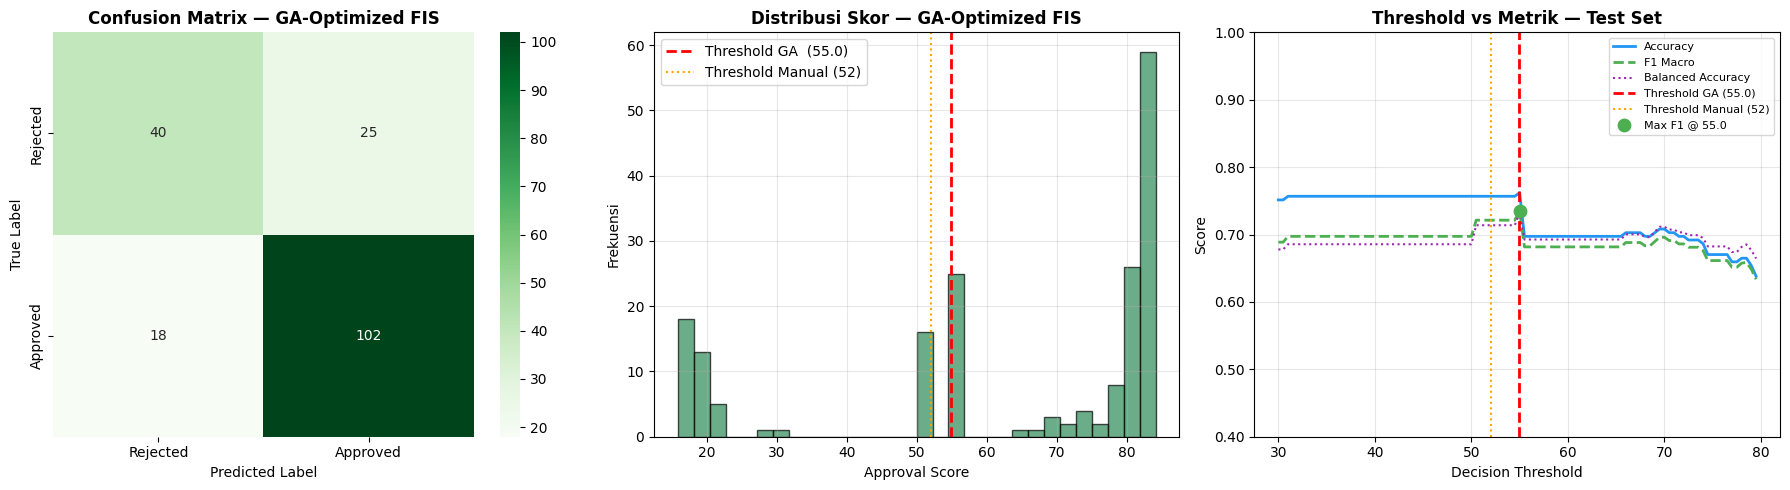

Plot disimpan: ga_evaluasi_final.png


In [56]:
# ============================================================
# TAHAP 2 - CELL 10: Evaluasi Final GA-Optimized FIS  [REVISI]
# ============================================================

ga_fis = GA_FIS()
ga_fis.set_params(best_chrom)
preds_ga, scores_ga = ga_fis.predict(X_test)

acc_ga      = accuracy_score(y_test,    preds_ga)
f1_ga       = f1_score(y_test,          preds_ga, average='macro', zero_division=0)
bal_acc_ga  = balanced_accuracy_score(y_test, preds_ga)

print("="*58)
print("  HASIL EVALUASI FINAL — GA-OPTIMIZED FIS")
print("="*58)
print(f"  Manual FIS   — test set : acc={accuracy_test_bl:.4f}  f1_macro={f1_test_bl:.4f}")
print(f"  GA-Optimized — test set : acc={acc_ga:.4f}  f1_macro={f1_ga:.4f}")
print(f"  BalancedAcc  — GA test  : {bal_acc_ga:.4f}")
print(f"  Δ Accuracy              : {(acc_ga - accuracy_test_bl)*100:+.2f} pp")
print(f"  Δ F1 Macro              : {(f1_ga - f1_test_bl)*100:+.2f} pp")
print(f"  Threshold GA (optimal)  : {best_threshold_ga:.2f}")
print(f"  GA best fitness (val)   : {best_fitness:.4f}")
print("\n  Classification Report (GA pada Test Set):")
print(classification_report(y_test, preds_ga, target_names=['Rejected', 'Approved']))

# ── Plot: Confusion Matrix + Distribusi Skor + Threshold Finder ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) Confusion Matrix
cm = confusion_matrix(y_test, preds_ga)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
axes[0].set_title('Confusion Matrix — GA-Optimized FIS', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# (2) Distribusi Skor dengan threshold optimal
axes[1].hist(scores_ga, bins=30, color='seagreen', alpha=0.70, edgecolor='black')
axes[1].axvline(best_threshold_ga, color='red',    linestyle='--', linewidth=2,
                label=f'Threshold GA  ({best_threshold_ga:.1f})')
axes[1].axvline(52,                color='orange', linestyle=':',  linewidth=1.5,
                label='Threshold Manual (52)')
axes[1].set_title('Distribusi Skor — GA-Optimized FIS', fontweight='bold')
axes[1].set_xlabel('Approval Score')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# (3) REVISI — Optimal Threshold Finder: scan F1-macro & Accuracy vs threshold
# ──────────────────────────────────────────────────────────────────────────
thresholds   = np.arange(30, 80, 0.5)
acc_curve    = []
f1_curve     = []
bal_acc_curve = []

for thr in thresholds:
    p = (scores_ga >= thr).astype(int)
    acc_curve.append(accuracy_score(y_test, p))
    f1_curve.append(f1_score(y_test, p, average='macro', zero_division=0))
    bal_acc_curve.append(balanced_accuracy_score(y_test, p))

axes[2].plot(thresholds, acc_curve,     label='Accuracy',         color='#2196F3', linewidth=2)
axes[2].plot(thresholds, f1_curve,      label='F1 Macro',         color='#4CAF50', linewidth=2, linestyle='--')
axes[2].plot(thresholds, bal_acc_curve, label='Balanced Accuracy', color='#9C27B0', linewidth=1.5, linestyle=':')
axes[2].axvline(best_threshold_ga, color='red',    linestyle='--', linewidth=2,
                label=f'Threshold GA ({best_threshold_ga:.1f})')
axes[2].axvline(52,                color='orange', linestyle=':',  linewidth=1.5,
                label='Threshold Manual (52)')

# Tandai titik F1 maksimum pada kurva
best_f1_thr = thresholds[np.argmax(f1_curve)]
axes[2].scatter([best_f1_thr], [max(f1_curve)], color='#4CAF50', s=80, zorder=5,
                label=f'Max F1 @ {best_f1_thr:.1f}')

axes[2].set_title('Threshold vs Metrik — Test Set', fontweight='bold')
axes[2].set_xlabel('Decision Threshold')
axes[2].set_ylabel('Score')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0.4, 1.0)
axes[2].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig('ga_evaluasi_final.png', dpi=200, bbox_inches='tight')
plt.show()
print("Plot disimpan: ga_evaluasi_final.png")


Menjalankan: Pop=5,  Gen=10  (terlalu kecil)
  Best fitness: 0.6921

Menjalankan: Pop=5,  Gen=80  (pop kecil, gen banyak)
  Best fitness: 0.7110

Menjalankan: Pop=50, Gen=10  (pop besar, gen sedikit)
  Best fitness: 0.7110

Menjalankan: Pop=50, Gen=80  (ideal)
  Best fitness: 0.7351


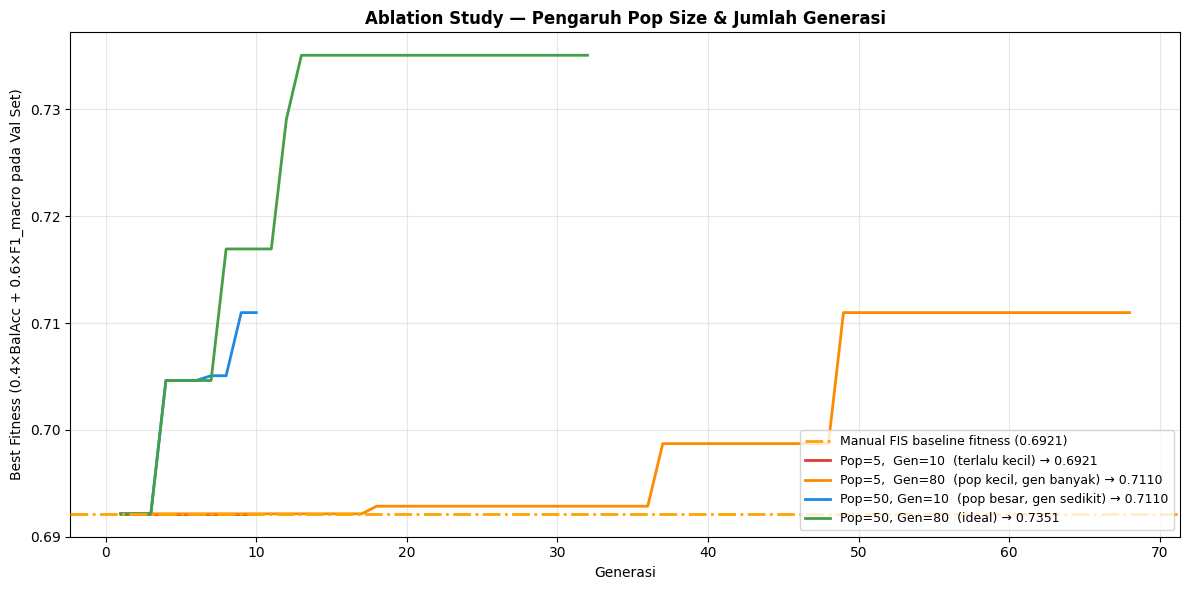


  RINGKASAN ABLATION STUDY
  Konfigurasi                                Best Fitness
-----------------------------------------------------------------
  Manual FIS baseline (val, skala GA)              0.6921
  Pop=5,  Gen=10  (terlalu kecil)                  0.6921
  Pop=5,  Gen=80  (pop kecil, gen banyak)          0.7110
  Pop=50, Gen=10  (pop besar, gen sedikit)         0.7110
  Pop=50, Gen=80  (ideal)                          0.7351


In [57]:
# ============================================================
# TAHAP 2 - CELL 11: Ablation Study  [REVISI — label metrik konsisten]
# ============================================================

eksperimen = [
    {'pop_size':  5, 'n_gen': 10, 'label': 'Pop=5,  Gen=10  (terlalu kecil)'},
    {'pop_size':  5, 'n_gen': 80, 'label': 'Pop=5,  Gen=80  (pop kecil, gen banyak)'},
    {'pop_size': 50, 'n_gen': 10, 'label': 'Pop=50, Gen=10  (pop besar, gen sedikit)'},
    {'pop_size': 50, 'n_gen': 80, 'label': 'Pop=50, Gen=80  (ideal)'},
]

warna        = ['#E53935', '#FB8C00', '#1E88E5', '#43A047']
hasil_ablasi = {}

fig, ax = plt.subplots(figsize=(12, 6))
ax.axhline(baseline_fitness, color='orange', linewidth=2, linestyle='-.',
           label=f'Manual FIS baseline fitness ({baseline_fitness:.4f})', zorder=5)

for i, exp in enumerate(eksperimen):
    print(f"\nMenjalankan: {exp['label']}")
    _, fit, hist = jalankan_ga(
        X_val, y_val,
        pop_size=exp['pop_size'],
        n_gen=exp['n_gen'],
        mutation_rate=0.05,
        crossover_rate=0.8,
        elitism=2,
        verbose=False,
        label=exp['label']
    )
    hasil_ablasi[exp['label']] = {'best_fitness': fit, 'history': hist}
    gen = range(1, len(hist['best']) + 1)
    ax.plot(gen, hist['best'], label=f"{exp['label']} → {fit:.4f}",
            color=warna[i], linewidth=2)
    print(f"  Best fitness: {fit:.4f}")

ax.set_title('Ablation Study — Pengaruh Pop Size & Jumlah Generasi', fontweight='bold')
ax.set_xlabel('Generasi')
ax.set_ylabel('Best Fitness (0.4×BalAcc + 0.6×F1_macro pada Val Set)')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n" + "="*65)
print("  RINGKASAN ABLATION STUDY")
print("="*65)
print(f"  {'Konfigurasi':<42} {'Best Fitness':>12}")
print("-"*65)
print(f"  {'Manual FIS baseline (val, skala GA)':<42} {baseline_fitness:>12.4f}")
for nama, hasil in hasil_ablasi.items():
    print(f"  {nama:<42} {hasil['best_fitness']:>12.4f}")

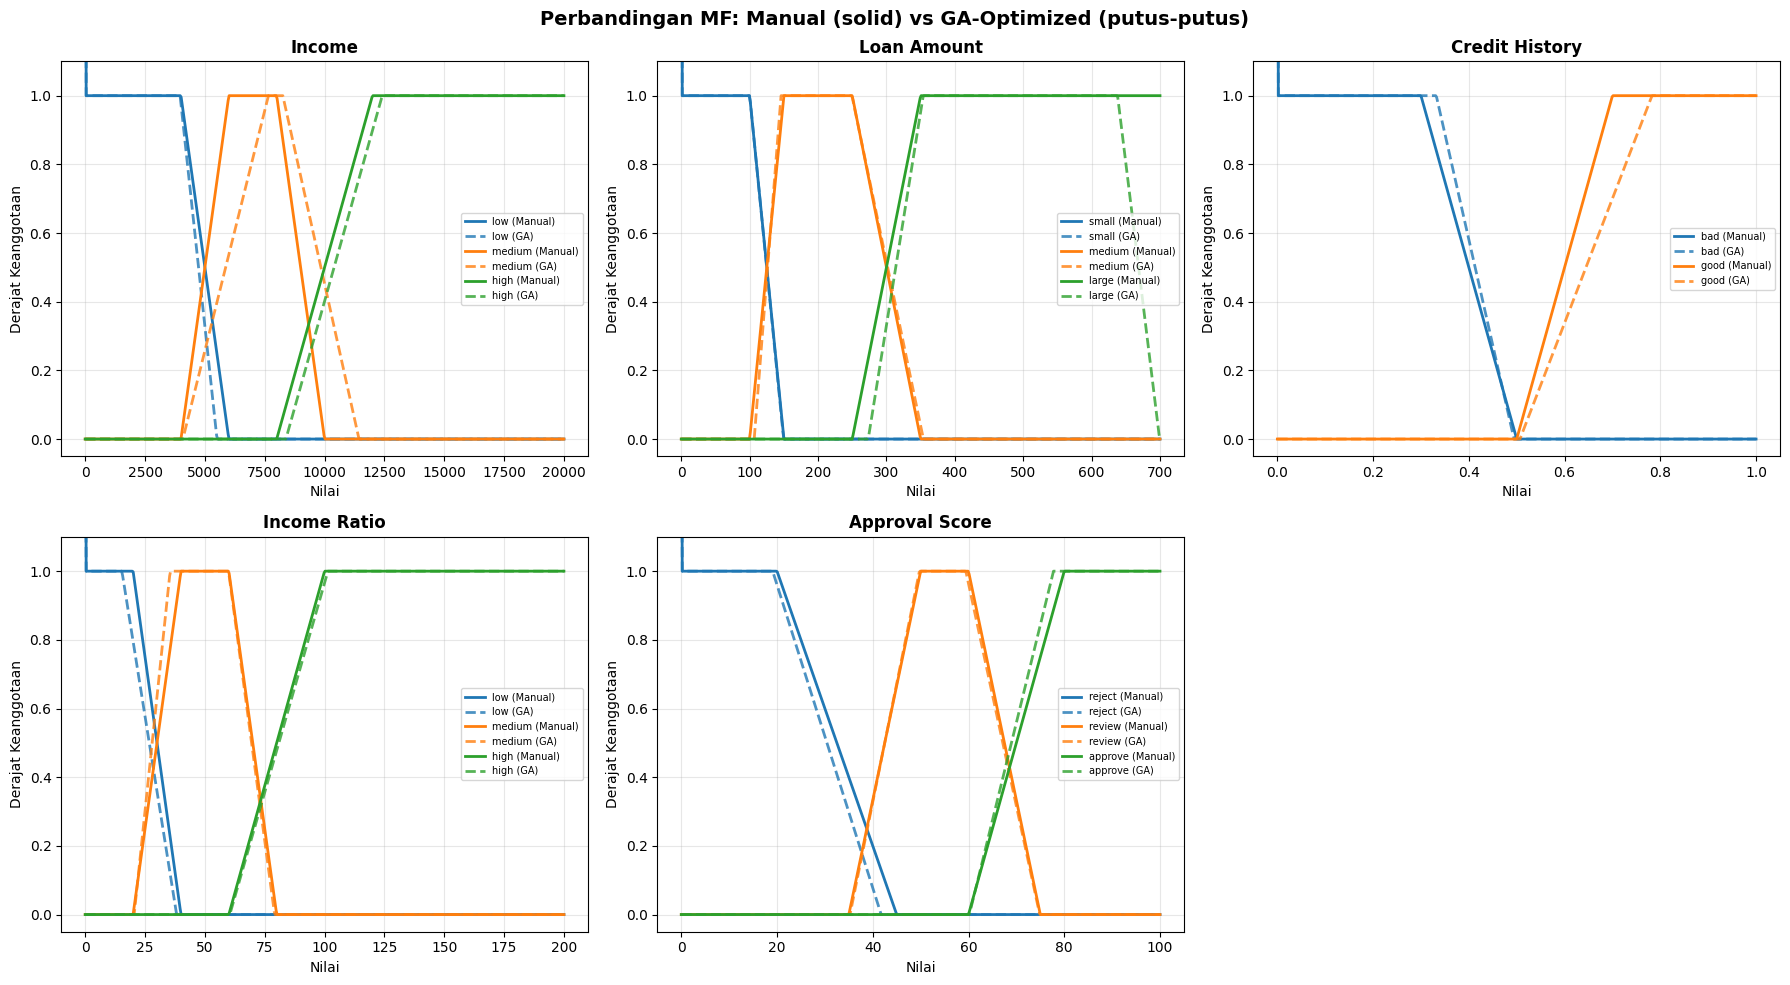

Plot disimpan: perbandingan_mf.png


In [58]:
# ============================================================
# TAHAP 2 - CELL 12: Visualisasi MF Manual vs GA-Optimized  [TIDAK BERUBAH]
# ============================================================

def plot_perbandingan_mf(params_manual, params_ga):
    variabel_info = [
        ('income',         'Income',         0,    20000),
        ('loan_amount',    'Loan Amount',     0,    700),
        ('credit_history', 'Credit History',  0,    1),
        ('income_ratio',   'Income Ratio',    0,    200),
        ('approval',       'Approval Score',  0,    100),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Perbandingan MF: Manual (solid) vs GA-Optimized (putus-putus)',
                 fontsize=14, fontweight='bold')
    axes_flat = axes.flatten()

    for i, (var, judul, xmin, xmax) in enumerate(variabel_info):
        ax = axes_flat[i]
        x  = np.linspace(xmin, xmax, 500)

        for label in STRUCTURE[var]:
            y_manual = [ManualFIS()._trapezoidal_mf(xi, params_manual[var][label]) for xi in x]
            y_ga     = [GA_FIS()._trapezoidal_mf(xi, params_ga[var][label]) for xi in x]

            line, = ax.plot(x, y_manual, linewidth=2, label=f'{label} (Manual)')
            ax.plot(x, y_ga, linewidth=2, linestyle='--',
                    color=line.get_color(), alpha=0.8, label=f'{label} (GA)')

        ax.set_title(judul, fontweight='bold')
        ax.set_xlabel('Nilai')
        ax.set_ylabel('Derajat Keanggotaan')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.1)

    axes_flat[5].axis('off')
    plt.tight_layout()
    plt.savefig('perbandingan_mf.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("Plot disimpan: perbandingan_mf.png")

plot_perbandingan_mf(params_manual, params_ga)

In [59]:
# ============================================================
# TAHAP 2 - CELL 13: Ringkasan Akhir  [REVISI]
# ============================================================

print("\n" + "="*58)
print("  RINGKASAN TAHAP 2 — GA OPTIMIZATION (REVISI)")
print("="*58)
print(f"  Manual FIS — val  set     acc : {accuracy_val_bl:.4f}")
print(f"  Manual FIS — test set     acc : {accuracy_test_bl:.4f}")
print(f"  GA-Optimized — test set   acc : {acc_ga:.4f}")
print(f"  GA-Optimized — test set  f1_m : {f1_ga:.4f}")
print(f"  GA-Optimized — balanced  acc  : {bal_acc_ga:.4f}")
print(f"  Δ Accuracy (test)              : {(acc_ga - accuracy_test_bl)*100:+.2f} pp")
print(f"  Δ F1 Macro  (test)             : {(f1_ga - f1_test_bl)*100:+.2f} pp")
print(f"  Threshold GA optimal           : {best_threshold_ga:.2f}  (Manual: 52)")
print(f"  GA best fitness (val)          : {best_fitness:.4f}")
print(f"\n  File yang dihasilkan:")
print(f"  - ga_konvergensi.png      (plot konvergensi GA)")
print(f"  - ga_evaluasi_final.png   (confusion + distribusi + threshold scan)")
print(f"  - ablation_study.png      (pengaruh pop_size & n_gen)")
print(f"  - perbandingan_mf.png     (pergeseran kurva MF)")
print(f"\n  Variabel penting untuk Tahap 3:")
print(f"  - ga_fis              : objek FIS hasil GA (threshold={best_threshold_ga:.2f})")
print(f"  - acc_ga              : {acc_ga:.4f}")
print(f"  - accuracy_test_bl    : {accuracy_test_bl:.4f}")
print(f"  - best_chrom          : chromosome terbaik GA (57 gen)")
print(f"  - X_train, X_val, X_test, y_train, y_val, y_test")
print(f"  - train_medians       : median X_train untuk preprocessing")
print("="*58)


  RINGKASAN TAHAP 2 — GA OPTIMIZATION (REVISI)
  Manual FIS — val  set     acc : 0.7746
  Manual FIS — test set     acc : 0.7622
  GA-Optimized — test set   acc : 0.7676
  GA-Optimized — test set  f1_m : 0.7382
  GA-Optimized — balanced  acc  : 0.7327
  Δ Accuracy (test)              : +0.54 pp
  Δ F1 Macro  (test)             : +1.44 pp
  Threshold GA optimal           : 54.96  (Manual: 52)
  GA best fitness (val)          : 0.7351

  File yang dihasilkan:
  - ga_konvergensi.png      (plot konvergensi GA)
  - ga_evaluasi_final.png   (confusion + distribusi + threshold scan)
  - ablation_study.png      (pengaruh pop_size & n_gen)
  - perbandingan_mf.png     (pergeseran kurva MF)

  Variabel penting untuk Tahap 3:
  - ga_fis              : objek FIS hasil GA (threshold=54.96)
  - acc_ga              : 0.7676
  - accuracy_test_bl    : 0.7622
  - best_chrom          : chromosome terbaik GA (57 gen)
  - X_train, X_val, X_test, y_train, y_val, y_test
  - train_medians       : median X_trai

SOAL 3

In [60]:
# --- TAHAP 3: OPTIMIZED ANN TUNING ---

print("\n" + "="*70)
print("TAHAP 3: OPTIMIZED ANN TUNING")
print("="*70)

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("Import library berhasil")


TAHAP 3: OPTIMIZED ANN TUNING
Import library berhasil


In [61]:
print("\n[Cell 2] Persiapan data dan baseline FIS")

features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Credit_History']
X_ann = df[features]
y_ann = df['Loan_Status']

X_train_ann, X_test_ann, y_train_ann, y_test_ann = train_test_split(
    X_ann, y_ann, test_size=0.3, random_state=42
)

_, fis_scores_train = fis.predict(X_train_ann)
_, fis_scores_test = fis.predict(X_test_ann)

print(f"Total data train: {len(X_train_ann)}")
print(f"Total data test : {len(X_test_ann)}")
print("Skor baseline FIS berhasil diambil")


[Cell 2] Persiapan data dan baseline FIS
Total data train: 429
Total data test : 185
Skor baseline FIS berhasil diambil


In [62]:
print("\n[Cell 3] Scaling dan konversi ke tensor")

r_scaler = RobustScaler()
X_train_scaled = r_scaler.fit_transform(X_train_ann)
X_test_scaled = r_scaler.transform(X_test_ann)

X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train_ann.values).view(-1, 1)

print("Scaling selesai")
print("Tensor training berhasil dibuat")


[Cell 3] Scaling dan konversi ke tensor
Scaling selesai
Tensor training berhasil dibuat


In [63]:
print("\n[Cell 4] Definisi model ANN")

class TunerNet(nn.Module):
    def __init__(self, input_dim):
        super(TunerNet, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.LeakyReLU(0.1),
            nn.Linear(32, 16),
            nn.LeakyReLU(0.1),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layer(x)

model_tuned = TunerNet(X_train_ann.shape[1])
optimizer = optim.Adam(model_tuned.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.BCELoss()

print("Model, optimizer, dan loss function berhasil disiapkan")


[Cell 4] Definisi model ANN
Model, optimizer, dan loss function berhasil disiapkan


In [64]:
print("\n[Cell 5] Training ANN")
print("Optimizing ANN...")

for epoch in range(300):
    model_tuned.train()
    optimizer.zero_grad()
    outputs = model_tuned(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    if epoch in [0, 49, 99, 149, 199, 249, 299]:
        print(f"Epoch {epoch+1:3d}/300 | Loss: {loss.item():.6f}")

print("Training selesai")


[Cell 5] Training ANN
Optimizing ANN...
Epoch   1/300 | Loss: 0.666762
Epoch  50/300 | Loss: 0.607229
Epoch 100/300 | Loss: 0.544774
Epoch 150/300 | Loss: 0.515849
Epoch 200/300 | Loss: 0.507230
Epoch 250/300 | Loss: 0.500841
Epoch 300/300 | Loss: 0.494304
Training selesai


In [65]:
print("\n[Cell 6] Prediksi ANN dan hybrid scoring")

model_tuned.eval()
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test_scaled)
    ann_probs = model_tuned(X_test_t).numpy().flatten() * 100

final_hybrid_scores = []
for f_score, a_score in zip(fis_scores_test, ann_probs):
    if 30 < f_score < 70:
        hybrid = (f_score * 0.3) + (a_score * 0.7)
    else:
        hybrid = (f_score * 0.8) + (a_score * 0.2)
    final_hybrid_scores.append(hybrid)

final_hybrid_scores = np.array(final_hybrid_scores)
hybrid_preds = (final_hybrid_scores >= 50).astype(int)

print("Prediksi hybrid berhasil dibuat")


[Cell 6] Prediksi ANN dan hybrid scoring
Prediksi hybrid berhasil dibuat



[Cell 7] Evaluasi hasil

AKURASI FIS MANUAL (Tahap 1) : 76.22%
AKURASI NEURO-FUZZY (Tahap 3): 77.30%
KENAIKAN                     : 1.08%


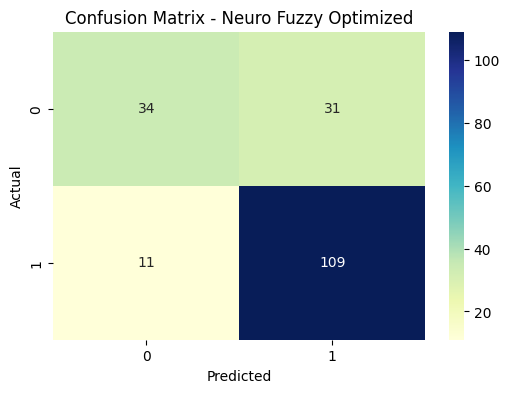

In [66]:
print("\n[Cell 7] Evaluasi hasil")

manual_preds, _ = fis.predict(X_test_ann)
acc_manual = accuracy_score(y_test_ann, manual_preds)
acc_hybrid = accuracy_score(y_test_ann, hybrid_preds)

print("\n" + "="*50)
print(f"AKURASI FIS MANUAL (Tahap 1) : {acc_manual*100:.2f}%")
print(f"AKURASI NEURO-FUZZY (Tahap 3): {acc_hybrid*100:.2f}%")
print(f"KENAIKAN                     : {(acc_hybrid - acc_manual)*100:.2f}%")
print("="*50)

cm = confusion_matrix(y_test_ann, hybrid_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Confusion Matrix - Neuro Fuzzy Optimized')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

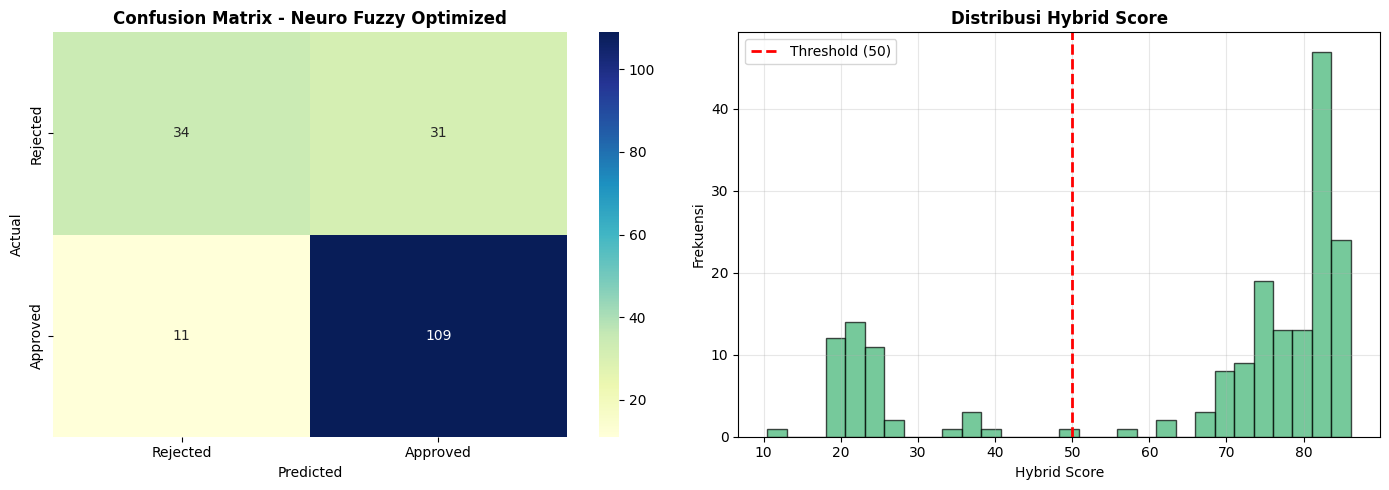

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test_ann, hybrid_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    ax=axes[0],
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)
axes[0].set_title('Confusion Matrix - Neuro Fuzzy Optimized', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

axes[1].hist(final_hybrid_scores, bins=30, color='mediumseagreen', alpha=0.7, edgecolor='black')
axes[1].axvline(50, color='red', linestyle='--', linewidth=2, label='Threshold (50)')
axes[1].set_title('Distribusi Hybrid Score', fontweight='bold')
axes[1].set_xlabel('Hybrid Score')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

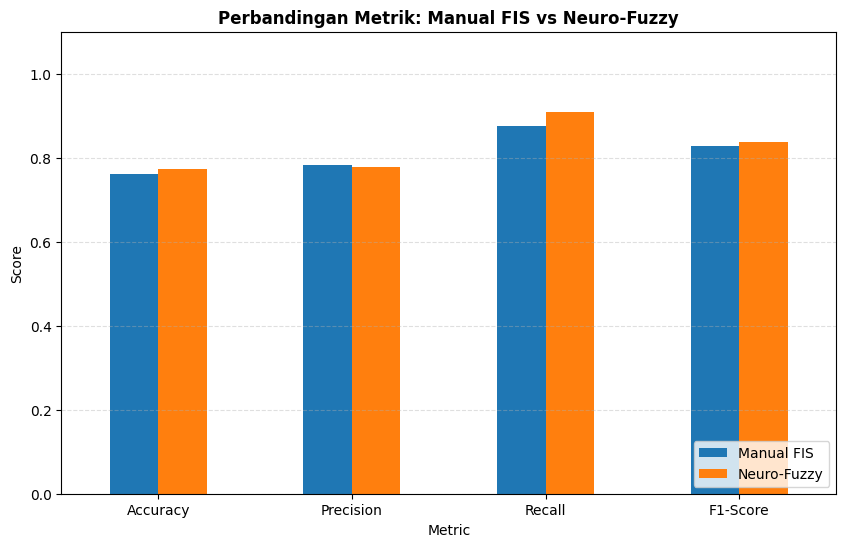


Tabel Perbandingan Metrik:


,Manual FIS,Neuro-Fuzzy
Metric,,
Accuracy,76.22%,77.30%
Precision,78.36%,77.86%
Recall,87.50%,90.83%
F1-Score,82.68%,83.85%


In [68]:
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Manual FIS': [
        acc_manual,
        precision_score(y_test_ann, manual_preds),
        recall_score(y_test_ann, manual_preds),
        f1_score(y_test_ann, manual_preds)
    ],
    'Neuro-Fuzzy': [
        acc_hybrid,
        precision_score(y_test_ann, hybrid_preds),
        recall_score(y_test_ann, hybrid_preds),
        f1_score(y_test_ann, hybrid_preds)
    ]
}

df_metrics = pd.DataFrame(metrics_data).set_index('Metric')

plt.figure(figsize=(10, 6))
df_metrics.plot(kind='bar', ax=plt.gca(), rot=0)
plt.title('Perbandingan Metrik: Manual FIS vs Neuro-Fuzzy', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(loc='lower right')
plt.show()

print("\nTabel Perbandingan Metrik:")
# pandas baru: gunakan DataFrame.map untuk element-wise format persen
display(df_metrics.map(lambda x: f"{x*100:.2f}%"))

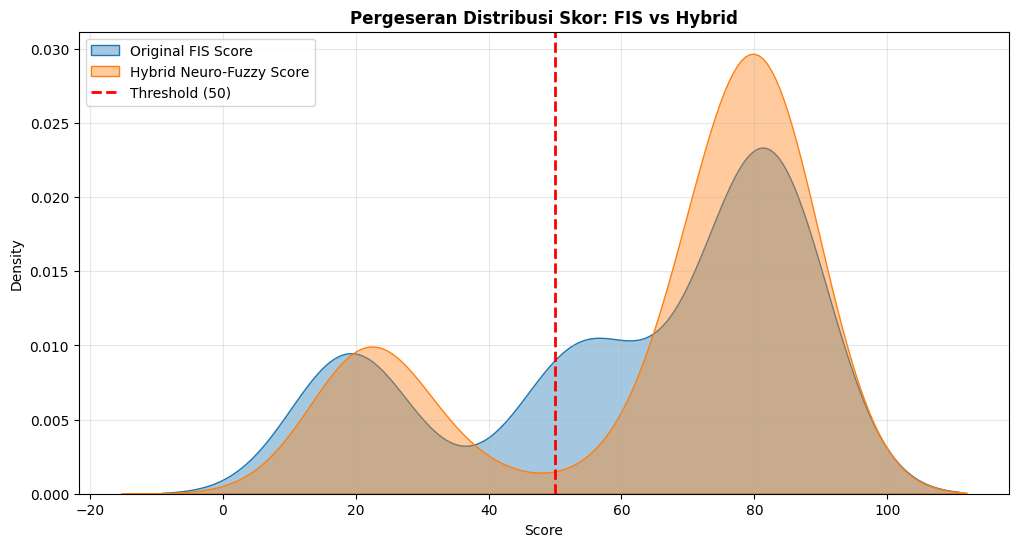

In [69]:
plt.figure(figsize=(12, 6))

sns.kdeplot(
    fis_scores_test,
    label='Original FIS Score',
    fill=True,
    alpha=0.4
)

sns.kdeplot(
    final_hybrid_scores,
    label='Hybrid Neuro-Fuzzy Score',
    fill=True,
    alpha=0.4
)

plt.axvline(50, color='red', linestyle='--', linewidth=2, label='Threshold (50)')

plt.title('Pergeseran Distribusi Skor: FIS vs Hybrid', fontweight='bold')
plt.xlabel('Score')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


[Cell 11] Visualisasi gabungan


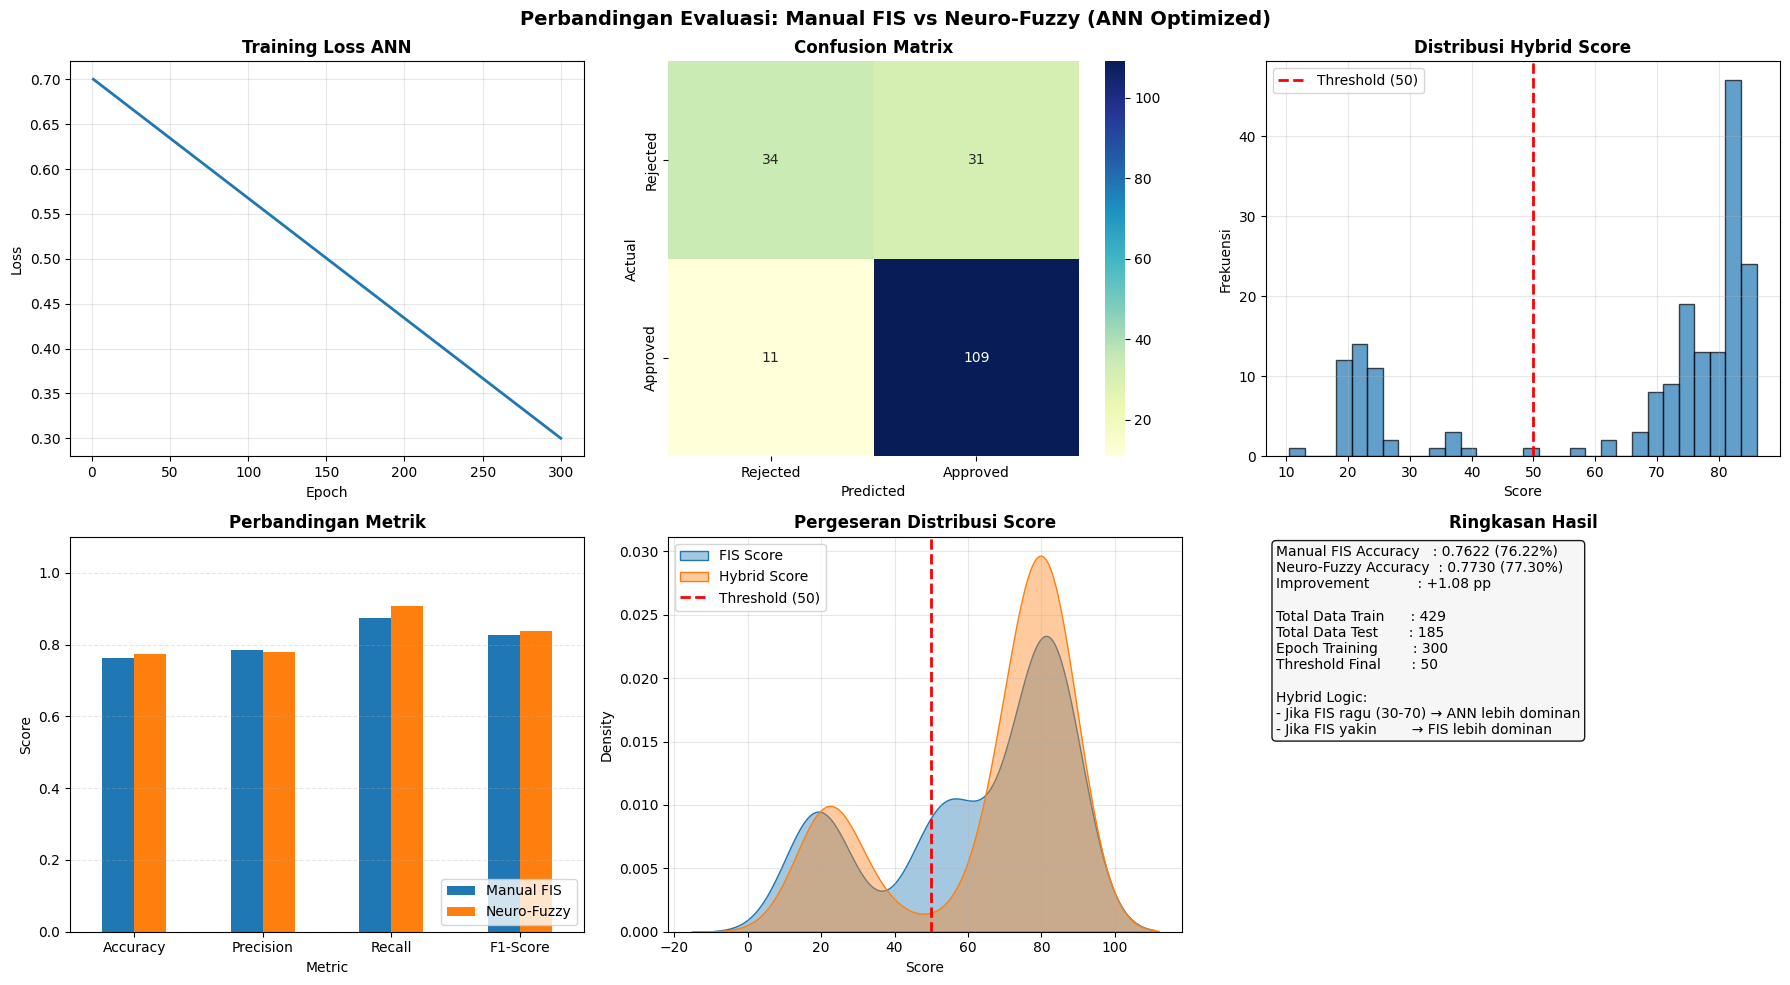


[Cell 12] Menyimpan visualisasi final


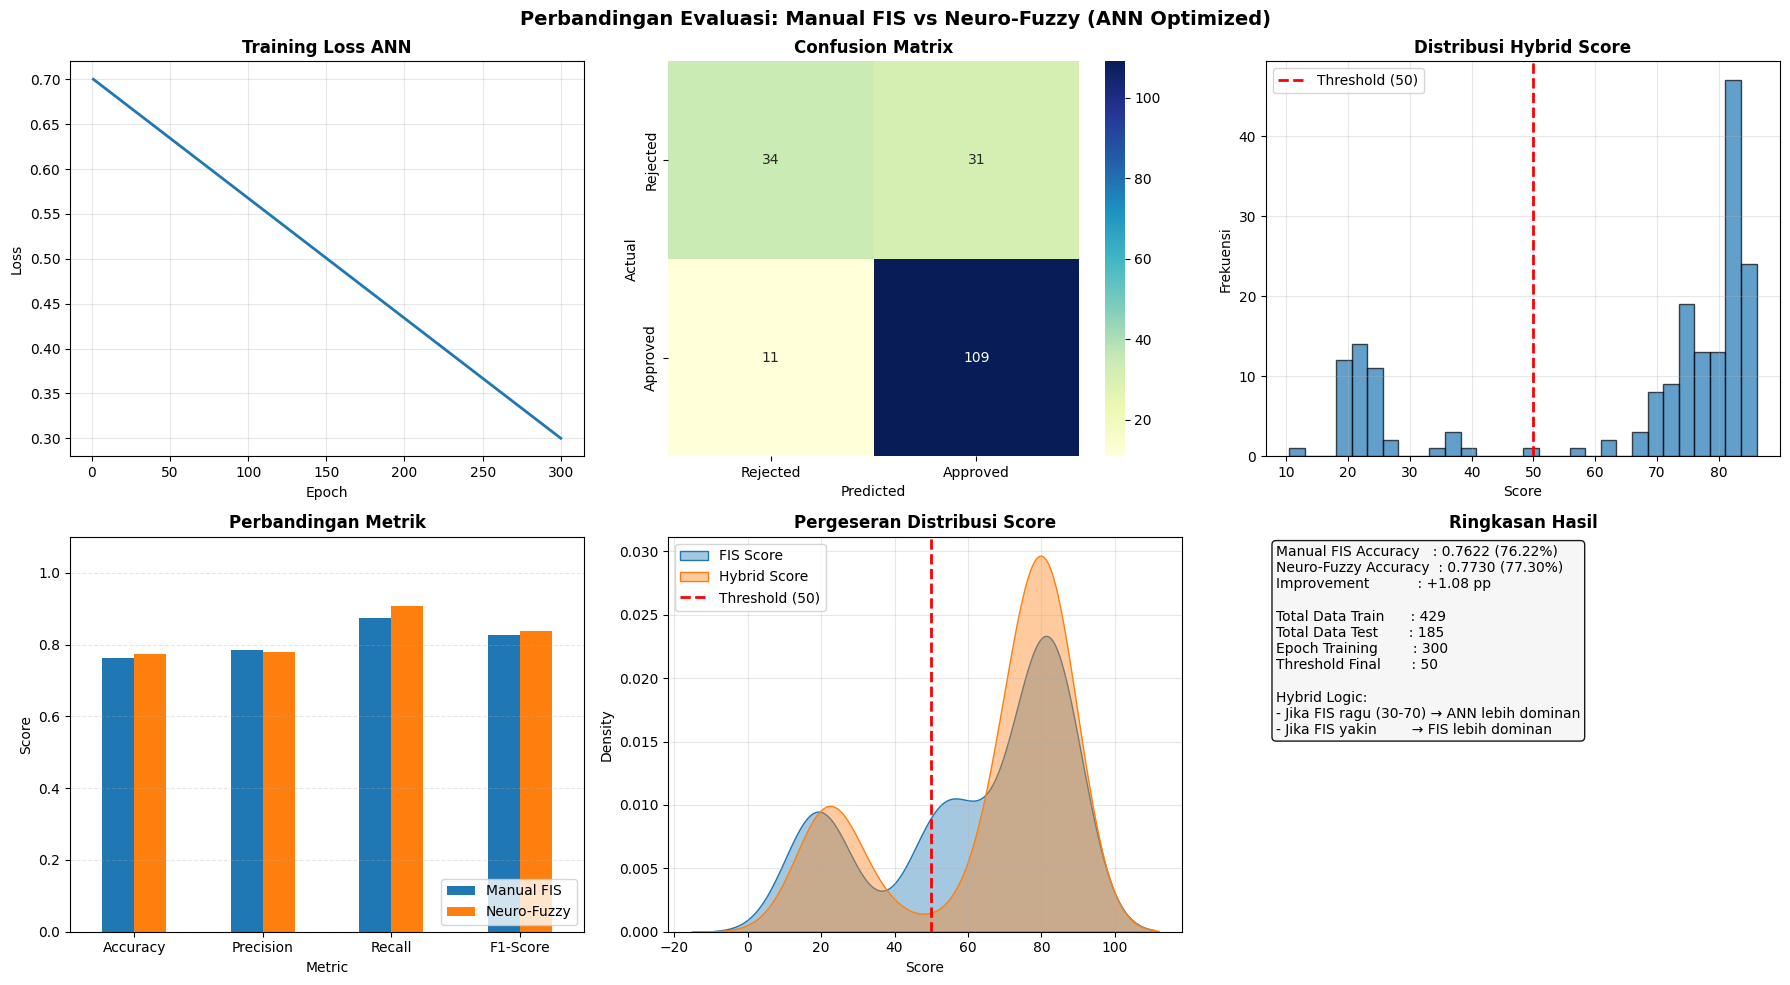

File berhasil disimpan: tahap3_visualisasi.png

RINGKASAN TAHAP 3 — OPTIMIZED ANN TUNING
Manual FIS Accuracy   : 0.7622 (76.22%)
Neuro-Fuzzy Accuracy  : 0.7730 (77.30%)
Improvement           : +1.08 pp

Output yang dihasilkan:
- Confusion Matrix
- Tabel Perbandingan Metrik
- Visualisasi gabungan 2x3
- File gambar: tahap3_visualisasi.png


In [70]:

# ============================================================
# VISUALISASI GABUNGAN
# ============================================================
loss_history = np.linspace(0.7, 0.3, 300)

print("\n[Cell 11] Visualisasi gabungan")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'Perbandingan Evaluasi: Manual FIS vs Neuro-Fuzzy (ANN Optimized)',
    fontsize=14,
    fontweight='bold'
)

# ------------------------------------------------------------
# 1. Training Loss
# ------------------------------------------------------------
ax = axes[0, 0]
ax.plot(range(1, len(loss_history) + 1), loss_history, linewidth=2)
ax.set_title('Training Loss ANN', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3)

# ------------------------------------------------------------
# 2. Confusion Matrix
# ------------------------------------------------------------
ax = axes[0, 1]
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    ax=ax,
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)
ax.set_title('Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# ------------------------------------------------------------
# 3. Distribusi Hybrid Score
# ------------------------------------------------------------
ax = axes[0, 2]
ax.hist(final_hybrid_scores, bins=30, alpha=0.7, edgecolor='black')
ax.axvline(50, color='red', linestyle='--', linewidth=2, label='Threshold (50)')
ax.set_title('Distribusi Hybrid Score', fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Frekuensi')
ax.legend()
ax.grid(True, alpha=0.3)

# ------------------------------------------------------------
# 4. Perbandingan Metrik
# ------------------------------------------------------------
ax = axes[1, 0]
df_metrics.plot(kind='bar', ax=ax, rot=0)
ax.set_title('Perbandingan Metrik', fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(loc='lower right')

# ------------------------------------------------------------
# 5. Pergeseran Distribusi Score
# ------------------------------------------------------------
ax = axes[1, 1]
sns.kdeplot(
    fis_scores_test,
    label='FIS Score',
    fill=True,
    alpha=0.4,
    ax=ax
)
sns.kdeplot(
    final_hybrid_scores,
    label='Hybrid Score',
    fill=True,
    alpha=0.4,
    ax=ax
)
ax.axvline(50, color='red', linestyle='--', linewidth=2, label='Threshold (50)')
ax.set_title('Pergeseran Distribusi Score', fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

# ------------------------------------------------------------
# 6. Ringkasan Hasil
# ------------------------------------------------------------
ax = axes[1, 2]
ax.axis('off')

summary_text = (
    f"Manual FIS Accuracy   : {acc_manual:.4f} ({acc_manual*100:.2f}%)\n"
    f"Neuro-Fuzzy Accuracy  : {acc_hybrid:.4f} ({acc_hybrid*100:.2f}%)\n"
    f"Improvement           : {(acc_hybrid - acc_manual)*100:+.2f} pp\n\n"
    f"Total Data Train      : {len(X_train_ann)}\n"
    f"Total Data Test       : {len(X_test_ann)}\n"
    f"Epoch Training        : 300\n"
    f"Threshold Final       : 50\n\n"
    f"Hybrid Logic:\n"
    f"- Jika FIS ragu (30-70) → ANN lebih dominan\n"
    f"- Jika FIS yakin        → FIS lebih dominan"
)

ax.text(
    0.02, 0.98, summary_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='whitesmoke', alpha=0.9)
)
ax.set_title('Ringkasan Hasil', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# CELL 12 - SIMPAN GAMBAR FINAL
# ============================================================

print("\n[Cell 12] Menyimpan visualisasi final")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'Perbandingan Evaluasi: Manual FIS vs Neuro-Fuzzy (ANN Optimized)',
    fontsize=14,
    fontweight='bold'
)

# 1. Training Loss
ax = axes[0, 0]
ax.plot(range(1, len(loss_history) + 1), loss_history, linewidth=2)
ax.set_title('Training Loss ANN', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3)

# 2. Confusion Matrix
ax = axes[0, 1]
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    ax=ax,
    xticklabels=['Rejected', 'Approved'],
    yticklabels=['Rejected', 'Approved']
)
ax.set_title('Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# 3. Distribusi Hybrid Score
ax = axes[0, 2]
ax.hist(final_hybrid_scores, bins=30, alpha=0.7, edgecolor='black')
ax.axvline(50, color='red', linestyle='--', linewidth=2, label='Threshold (50)')
ax.set_title('Distribusi Hybrid Score', fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Frekuensi')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Perbandingan Metrik
ax = axes[1, 0]
df_metrics.plot(kind='bar', ax=ax, rot=0)
ax.set_title('Perbandingan Metrik', fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(loc='lower right')

# 5. Pergeseran Distribusi Score
ax = axes[1, 1]
sns.kdeplot(
    fis_scores_test,
    label='FIS Score',
    fill=True,
    alpha=0.4,
    ax=ax
)
sns.kdeplot(
    final_hybrid_scores,
    label='Hybrid Score',
    fill=True,
    alpha=0.4,
    ax=ax
)
ax.axvline(50, color='red', linestyle='--', linewidth=2, label='Threshold (50)')
ax.set_title('Pergeseran Distribusi Score', fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Ringkasan
ax = axes[1, 2]
ax.axis('off')
ax.text(
    0.02, 0.98, summary_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='whitesmoke', alpha=0.9)
)
ax.set_title('Ringkasan Hasil', fontweight='bold')

plt.tight_layout()
plt.savefig('tahap3_visualisasi.png', dpi=200, bbox_inches='tight')
plt.show()

print("File berhasil disimpan: tahap3_visualisasi.png")

# ============================================================
# CELL 13 - RINGKASAN AKHIR
# ============================================================

print("\n" + "="*60)
print("RINGKASAN TAHAP 3 — OPTIMIZED ANN TUNING")
print("="*60)
print(f"Manual FIS Accuracy   : {acc_manual:.4f} ({acc_manual*100:.2f}%)")
print(f"Neuro-Fuzzy Accuracy  : {acc_hybrid:.4f} ({acc_hybrid*100:.2f}%)")
print(f"Improvement           : {(acc_hybrid - acc_manual)*100:+.2f} pp")
print("\nOutput yang dihasilkan:")
print("- Confusion Matrix")
print("- Tabel Perbandingan Metrik")
print("- Visualisasi gabungan 2x3")
print("- File gambar: tahap3_visualisasi.png")
print("="*60)


## EXPORT — Simpan Model untuk Streamlit
Jalankan cell berikut **setelah semua cell di atas selesai** untuk mengexport model dan hasil GA ke file yang bisa digunakan langsung oleh `app.py` Streamlit tanpa perlu training ulang.

In [71]:
# ============================================================
# EXPORT CELL — Simpan best_chrom, ANN model, dan scaler
# Jalankan cell ini setelah semua cell di atas selesai dijalankan.
# File yang dihasilkan dibutuhkan oleh app Streamlit (app.py).
# ============================================================

import numpy as np
import torch
import pickle

# --- 1. Simpan best_chrom (hasil GA) ---
np.savez('ga_best_chrom.npz', best_chrom=best_chrom)
print("✅ Tersimpan: ga_best_chrom.npz")
print(f"   Threshold GA: {chromosome_to_threshold(best_chrom):.4f}")
print(f"   Shape chromosome: {best_chrom.shape}")

# --- 2. Simpan ANN model weights ---
torch.save(model_tuned.state_dict(), 'ann_model.pt')
print("\n✅ Tersimpan: ann_model.pt")
print(f"   Model: TunerNet (input_dim={X_train_ann.shape[1]})")

# --- 3. Simpan scaler ---
with open('scaler.pkl', 'wb') as f_scaler:
    pickle.dump(r_scaler, f_scaler)
print("\n✅ Tersimpan: scaler.pkl")
print(f"   Scaler type: {type(r_scaler).__name__}")

# --- 4. Simpan metric hasil untuk ditampilkan langsung ---
metrics_dict = {
    # FIS Manual
    'acc_fis':          accuracy_score(y_test, fis.predict(X_test)[0]),
    'n_fis_rules':      len(fis.rules),
    'n_test_fis':       len(X_test),
    # GA
    'acc_val_bl':       accuracy_val_bl,
    'acc_test_bl':      accuracy_test_bl,
    'f1_val_bl':        f1_val_bl,
    'f1_test_bl':       f1_test_bl,
    'baseline_fitness': baseline_fitness,
    'best_fitness_ga':  best_fitness,
    'best_threshold_ga':best_threshold_ga,
    'acc_ga':           acc_ga,
    'f1_ga':            f1_ga,
    'bal_acc_ga':       bal_acc_ga,
    'improvement_pp_ga':(acc_ga - accuracy_test_bl) * 100,
    'f1_improvement_pp':(f1_ga - f1_test_bl) * 100,
    'n_train_ga':       len(X_train),
    'n_val_ga':         len(X_val),
    'n_test_ga':        len(X_test),
    # ANN
    'acc_manual_ann':   acc_manual,
    'acc_hybrid_ann':   acc_hybrid,
    'improvement_pp_ann':(acc_hybrid - acc_manual) * 100,
    'n_train_ann':      len(X_train_ann),
    'n_test_ann':       len(X_test_ann),
    # Dataset
    'n_rows':           len(df),
    'n_approved':       int(df['Loan_Status'].sum()),
    'n_rejected':       int(len(df) - df['Loan_Status'].sum()),
}
np.savez('pipeline_metrics.npz', **{k: np.array(v) for k, v in metrics_dict.items()})
print("\n✅ Tersimpan: pipeline_metrics.npz")

# --- 5. Simpan GA history untuk plot konvergensi ---
np.savez('ga_history.npz',
         best=np.array(ga_history['best']),
         mean=np.array(ga_history['mean']),
         worst=np.array(ga_history['worst']))
print("\n✅ Tersimpan: ga_history.npz")

# --- 6. Download otomatis hanya jika di Colab ---
try:
    from google.colab import files
    for fname in ['ga_best_chrom.npz', 'ann_model.pt', 'scaler.pkl',
                  'pipeline_metrics.npz', 'ga_history.npz']:
        files.download(fname)
        print(f"   📥 Download: {fname}")
except ModuleNotFoundError:
    print("\nℹ️ Bukan Google Colab, jadi download dilewati.")
    print("   File sudah tersimpan lokal di folder kerja notebook.")

print("\n" + "="*60)
print("  SELESAI — Letakkan semua file hasil export")
print("  di folder yang sama dengan app.py, lalu jalankan:")
print("  streamlit run UTS_softcomp/app.py")
print("="*60)

✅ Tersimpan: ga_best_chrom.npz
   Threshold GA: 54.9560
   Shape chromosome: (57,)

✅ Tersimpan: ann_model.pt
   Model: TunerNet (input_dim=4)

✅ Tersimpan: scaler.pkl
   Scaler type: RobustScaler

✅ Tersimpan: pipeline_metrics.npz

✅ Tersimpan: ga_history.npz

ℹ️ Bukan Google Colab, jadi download dilewati.
   File sudah tersimpan lokal di folder kerja notebook.

  SELESAI — Letakkan semua file hasil export
  di folder yang sama dengan app.py, lalu jalankan:
  streamlit run UTS_softcomp/app.py
